In [1]:
import papermill as pm
from jaxcmr.helpers import find_project_root
from IPython.display import Image, display
import os


# Unified Model Fitting
Consolidated orchestrator using eCMR base params with pooled analyses and model configs.


In [2]:
base_params = {
    "redo_fits": False,
    "redo_sims": True,
    "redo_figures": True,
    "handle_elis": False,
    "filter_repeated_recalls": True,
    "base_run_tag": "50_set_likelihood_fixed_term",
    "experiment_count": 200,
    "max_subjects": 0,
    "base_data_tag": "TalmiEEG",
    "data_tag": "TalmiEEG",
    "data_path": "data/TalmiEEG.h5",
    "trial_query": "data['subject'] > -1",
    "target_directory": "projects/TalmiEEG/results/",
    "component_paths": {
        "mfc_create_fn": "jaxcmr.components.linear_memory.init_mfc",
        "mcf_create_fn": "jaxcmr.components.linear_memory.init_mcf",
        "context_create_fn": "jaxcmr.components.context.init",
        "termination_policy_create_fn": "jaxcmr.components.termination.NoStopTermination",
    },
    "sim_alg_path": "jaxcmr.simulation.simulate_study_free_recall_and_forced_stop",
    "loss_fn_path": "jaxcmr.loss.set_permutation_likelihood.MemorySearchLikelihoodFnGenerator",
    "fit_alg_path": "jaxcmr.fitting.ScipyDE",
    "seed": 0,
    "relative_tolerance": 0.001,
    "popsize": 15,
    "num_steps": 1000,
    "cross_rate": 0.9,
    "diff_w": 0.85,
    "best_of": 3,
    "comparison_analysis_configs": [
        {
            "target": "jaxcmr.analyses.cat_spc.plot_cat_spc",
            "figure_suffix": "cat_spc_negative",
            "kwargs": {"category_field": "condition", "category_values": [1]},
            "ylim": [0.2, 0.8],
        },
        {
            "target": "jaxcmr.analyses.cat_spc.plot_cat_spc",
            "figure_suffix": "cat_spc_neutral",
            "kwargs": {"category_field": "condition", "category_values": [2]},
            "ylim": [0.2, 0.8],
        },
        {"target": "jaxcmr.analyses.spc.plot_spc", "figure_suffix": "spc"},
        {"target": "jaxcmr.analyses.crp.plot_crp", "figure_suffix": "crp"},
        {"target": "jaxcmr.analyses.pnr.plot_pnr", "figure_suffix": "pnr"},
    ],
    "single_analysis_configs": [
        {
            "target": "jaxcmr.analyses.cat_spc.plot_cat_spc",
            "figure_suffix": "cat_spc",
            "kwargs": {
                "category_field": "condition",
                "category_values": [1, 2],
                "labels": ["Negative", "Neutral"],
            },
            "ylim": [0.2, 0.8],
            "color_cycle": ["red", "black"],
        },
        {
            "target": "jaxcmr.analyses.cat_lpp_by_recall.plot_cat_lpp_by_recall",
            "figure_suffix": "cat_lpp_by_recall_NEGATIVE_EARLYLPP",
            "kwargs": {
                "category_field": "condition",
                "labels": ["Recalled", "Unrecalled"],
                "category_value": 1,
                "contrast_name": "Negative",
                "lpp_field": "EarlyLPP",
            },
            "ylim": [-0.6, 2.2],
        },
        {
            "target": "jaxcmr.analyses.cat_lpp_by_recall.plot_cat_lpp_by_recall",
            "figure_suffix": "cat_lpp_by_recall_NEUTRAL_EARLYLPP",
            "kwargs": {
                "category_field": "condition",
                "labels": ["Recalled", "Unrecalled"],
                "category_value": 2,
                "contrast_name": "Neutral",
                "lpp_field": "EarlyLPP",
            },
            "ylim": [-0.6, 2.2],
        },
        {
            "target": "jaxcmr.analyses.cat_lpp_by_recall.plot_cat_lpp_by_recall",
            "figure_suffix": "cat_lpp_by_recall",
            "kwargs": {
                "category_field": "condition",
                "labels": [
                    "Recalled Negative",
                    "Unrecalled Negative",
                    "Recalled Neutral",
                    "Unrecalled Neutral",
                ],
                "category_value": [2, 1, 4, 3],
                "contrast_name": "Condition x Recall",
                "lpp_field": "EarlyLPP",
                "exclude_ci": True,
            },
            "ylim": [-0.6, 2.2],
        },
    ],
}

In [3]:
varied_parameters = [
    # # Strength-only EEG model (no context dynamics).
    # {
    #     "redo_fits": True,
    #     "redo_sims": True,
    #     "redo_figures": True,
    #     "model_name": "EEGStrength",
    #     "make_factory_path": "jaxcmr.models_eeg.eeg_strength.make_factory",
    #     "parameters": {
    #         "fixed": {
    #             "allow_repeated_recalls": False,
    #             "modulate_emotion_by_primacy": False,
    #         },
    #         "free": {
    #             "primacy_scale": [2.220446049250313e-16, 100.0],
    #             "primacy_decay": [2.220446049250313e-16, 100.0],
    #             "choice_sensitivity": [2.220446049250313e-16, 100.0],
    #             "lpp_threshold": [-5.0, 5.0],
    #             "lpp_slope": [2.220446049250313e-16, 10.0],
    #         },
    #     },
    # },
    # # Strength-only EEG model; multiplicative emotion–primacy rule.
    # {
    #     "redo_fits": True,
    #     "redo_sims": True,
    #     "redo_figures": True,
    #     "model_name": "EEGStrengthMultiplicative",
    #     "make_factory_path": "jaxcmr.models_eeg.eeg_strength.make_factory",
    #     "parameters": {
    #         "fixed": {
    #             "allow_repeated_recalls": False,
    #             "modulate_emotion_by_primacy": True,
    #         },
    #         "free": {
    #             "primacy_scale": [2.220446049250313e-16, 100.0],
    #             "primacy_decay": [2.220446049250313e-16, 100.0],
    #             "choice_sensitivity": [2.220446049250313e-16, 100.0],
    #             "lpp_threshold": [-5.0, 5.0],
    #             "lpp_slope": [2.220446049250313e-16, 10.0],
    #         },
    #     },
    # },
    # # Baseline CMR (no stop rule, no emotion/LPP channels).
    # {
    #     "model_name": "WeirdCMRNoStop",
    #     "make_factory_path": "jaxcmr.models.cmr.make_factory",
    #     "parameters": {
    #         "fixed": {
    #             "allow_repeated_recalls": False,
    #             "learn_after_context_update": False,
    #         },
    #         "free": {
    #             "encoding_drift_rate": [2.220446049250313e-16, 0.9999999999999998],
    #             "start_drift_rate": [2.220446049250313e-16, 0.9999999999999998],
    #             "recall_drift_rate": [2.220446049250313e-16, 0.9999999999999998],
    #             "shared_support": [2.220446049250313e-16, 100.0],
    #             "item_support": [2.220446049250313e-16, 100.0],
    #             "learning_rate": [2.220446049250313e-16, 0.9999999999999998],
    #             "primacy_scale": [2.220446049250313e-16, 100.0],
    #             "primacy_decay": [2.220446049250313e-16, 100.0],
    #             "choice_sensitivity": [2.220446049250313e-16, 100.0],
    #         },
    #     },
    # },
    # # Emotion-only CMR (no LPP terms, single-channel encoding).
    # {
    #     "redo_fits": False,
    #     "redo_sims": False,
    #     "redo_figures": True,
    #     "model_name": "EEGEmotionOnly",
    #     "make_factory_path": "jaxcmr.models_eeg.eeg_cmr.make_factory",
    #     "parameters": {
    #         "fixed": {
    #             "allow_repeated_recalls": False,
    #             "modulate_emotion_by_primacy": False,
    #             "learn_after_context_update": False,
    #             "lpp_main_scale": 0.0,
    #             "lpp_main_threshold": 0.0,
    #             "lpp_inter_scale": 0.0,
    #             "lpp_inter_threshold": 0.0,
    #         },
    #         "free": {
    #             "encoding_drift_rate": [2.220446049250313e-16, 0.9999999999999998],
    #             "start_drift_rate": [2.220446049250313e-16, 0.9999999999999998],
    #             "recall_drift_rate": [2.220446049250313e-16, 0.9999999999999998],
    #             "shared_support": [2.220446049250313e-16, 100.0],
    #             "item_support": [2.220446049250313e-16, 100.0],
    #             "learning_rate": [2.220446049250313e-16, 0.9999999999999998],
    #             "primacy_scale": [2.220446049250313e-16, 100.0],
    #             "primacy_decay": [2.220446049250313e-16, 100.0],
    #             "choice_sensitivity": [2.220446049250313e-16, 100.0],
    #             "emotion_scale": [2.220446049250313e-16, 10.0],
    #         },
    #     },
    # },
    # # Emotion-only CMR with multiplicative emotion–primacy rule.
    # {
    #     "model_name": "EEGEmotionOnlyMultiplicative",
    #     "make_factory_path": "jaxcmr.models_eeg.eeg_cmr.make_factory",
    #     "parameters": {
    #        "fixed": {
    #             "allow_repeated_recalls": False,
    #             "modulate_emotion_by_primacy": True,
    #             "learn_after_context_update": False,
    #             "lpp_main_scale": 0.0,
    #             "lpp_main_threshold": 0.0,
    #             "lpp_inter_scale": 0.0,
    #             "lpp_inter_threshold": 0.0,
    #         },
    #         "free": {
    #             "encoding_drift_rate": [2.220446049250313e-16, 0.9999999999999998],
    #             "start_drift_rate": [2.220446049250313e-16, 0.9999999999999998],
    #             "recall_drift_rate": [2.220446049250313e-16, 0.9999999999999998],
    #             "shared_support": [2.220446049250313e-16, 100.0],
    #             "item_support": [2.220446049250313e-16, 100.0],
    #             "learning_rate": [2.220446049250313e-16, 0.9999999999999998],
    #             "primacy_scale": [2.220446049250313e-16, 100.0],
    #             "primacy_decay": [2.220446049250313e-16, 100.0],
    #             "choice_sensitivity": [2.220446049250313e-16, 100.0],
    #             "emotion_scale": [2.220446049250313e-16, 10.0],
    #         },
    #     },
    # },
    # # LPP-only CMR (no emotion main effect; linear LPP main + interaction terms).
    # {
    #     "redo_fits": False,
    #     "redo_sims": False,
    #     "redo_figures": True,
    #     "model_name": "EEGLPPOnly",
    #     "make_factory_path": "jaxcmr.models_eeg.eeg_cmr.make_factory",
    #     "parameters": {
    #         "fixed": {
    #             "allow_repeated_recalls": False,
    #             "modulate_emotion_by_primacy": False,
    #             "learn_after_context_update": False,
    #             "emotion_scale": 0.0,
    #             "lpp_inter_scale": 0.0,
    #             "lpp_inter_threshold": 0.0,
    #         },
    #         "free": {
    #             "encoding_drift_rate": [2.22e-16, 1.0],
    #             "start_drift_rate": [2.22e-16, 1.0],
    #             "recall_drift_rate": [2.22e-16, 1.0],
    #             "shared_support": [2.22e-16, 100.0],
    #             "item_support": [2.22e-16, 100.0],
    #             "learning_rate": [2.22e-16, 1.0],
    #             "primacy_scale": [2.22e-16, 100.0],
    #             "primacy_decay": [2.22e-16, 100.0],
    #             "choice_sensitivity": [2.22e-16, 100.0],
    #             "lpp_main_scale": [2.22e-16, 100.0],
    #             "lpp_main_threshold": [-5.0, 5.0],
    #         },
    #     },
    # },
    # LPP-only CMR, parsimonious (threshold fixed to 0; k=10).
    {
        "redo_fits": True,
        "redo_sims": True,
        "redo_figures": True,
        "model_name": "EEGLPPParsimonious",
        "make_factory_path": "jaxcmr.models_eeg.eeg_cmr.make_factory",
        "parameters": {
            "fixed": {
                "allow_repeated_recalls": False,
                "modulate_emotion_by_primacy": False,
                "learn_after_context_update": False,
                "emotion_scale": 0.0,
                "lpp_main_threshold": 0.0,
                "lpp_inter_scale": 0.0,
                "lpp_inter_threshold": 0.0,
            },
            "free": {
                "encoding_drift_rate": [2.220446049250313e-16, 0.9999999999999998],
                "start_drift_rate": [2.220446049250313e-16, 0.9999999999999998],
                "recall_drift_rate": [2.220446049250313e-16, 0.9999999999999998],
                "shared_support": [2.220446049250313e-16, 100.0],
                "item_support": [2.220446049250313e-16, 100.0],
                "learning_rate": [2.220446049250313e-16, 0.9999999999999998],
                "primacy_scale": [2.220446049250313e-16, 100.0],
                "primacy_decay": [2.220446049250313e-16, 100.0],
                "choice_sensitivity": [2.220446049250313e-16, 100.0],
                "lpp_main_scale": [2.220446049250313e-16, 100.0],
            },
        },
    },
    # # LPP-only CMR with nonlinear (exponent) LPP main + interaction terms.
    # {
    #     "redo_fits": False,
    #     "redo_sims": False,
    #     "redo_figures": True,
    #     "model_name": "EEGLPPExponentOnly",
    #     "make_factory_path": "jaxcmr.models_eeg.eeg_cmr.make_factory",
    #     "parameters": {
    #         "fixed": {
    #             "allow_repeated_recalls": False,
    #             "modulate_emotion_by_primacy": False,
    #             "learn_after_context_update": False,
    #             "emotion_scale": 0.0,
    #             "lpp_main_scale": 1.0,
    #             "lpp_inter_scale": 0.0,
    #             "lpp_inter_threshold": 0.0,
    #             "lpp_inter_exponent": 1.0,
    #         },
    #         "free": {
    #             "encoding_drift_rate": [2.220446049250313e-16, 0.9999999999999998],
    #             "start_drift_rate": [2.220446049250313e-16, 0.9999999999999998],
    #             "recall_drift_rate": [2.220446049250313e-16, 0.9999999999999998],
    #             "shared_support": [2.220446049250313e-16, 100.0],
    #             "item_support": [2.220446049250313e-16, 100.0],
    #             "learning_rate": [2.220446049250313e-16, 0.9999999999999998],
    #             "primacy_scale": [2.220446049250313e-16, 100.0],
    #             "primacy_decay": [2.220446049250313e-16, 100.0],
    #             "choice_sensitivity": [2.220446049250313e-16, 100.0],
    #             "lpp_main_exponent": [0.5, 50.0],
    #             "lpp_main_threshold": [-5.0, 5.0],
    #         },
    #     },
    # },
    # # EEG-CMR main effects (emotion + LPP main, no interaction).
    # {
    #     "redo_fits": False,
    #     "redo_sims": False,
    #     "redo_figures": True,
    #     "model_name": "EEGMainEffects",
    #     "make_factory_path": "jaxcmr.models_eeg.eeg_cmr.make_factory",
    #     "parameters": {
    #         "fixed": {
    #             "allow_repeated_recalls": False,
    #             "modulate_emotion_by_primacy": False,
    #             "learn_after_context_update": False,
    #             "lpp_inter_scale": 0.0,
    #             "lpp_inter_threshold": 0.0,
    #         },
    #         "free": {
    #             "encoding_drift_rate": [2.220446049250313e-16, 0.9999999999999998],
    #             "start_drift_rate": [2.220446049250313e-16, 0.9999999999999998],
    #             "recall_drift_rate": [2.220446049250313e-16, 0.9999999999999998],
    #             "shared_support": [2.220446049250313e-16, 100.0],
    #             "item_support": [2.220446049250313e-16, 100.0],
    #             "learning_rate": [2.220446049250313e-16, 0.9999999999999998],
    #             "primacy_scale": [2.220446049250313e-16, 100.0],
    #             "primacy_decay": [2.220446049250313e-16, 100.0],
    #             "choice_sensitivity": [2.220446049250313e-16, 100.0],
    #             "emotion_scale": [2.220446049250313e-16, 10.0],
    #             "lpp_main_scale": [2.220446049250313e-16, 100.0],
    #             "lpp_main_threshold": [-5.0, 5.0],
    #         },
    #     },
    # },
    # # EEG-eCMR two-layer main effects (emotion + LPP main, no interaction).
    # {
    #     "redo_fits": True,
    #     "redo_sims": True,
    #     "redo_figures": True,
    #     "model_name": "EEGTwoLayerMainEffects",
    #     "make_factory_path": "jaxcmr.models_eeg.eeg_ecmr.make_factory",
    #     "parameters": {
    #         "fixed": {
    #             "allow_repeated_recalls": False,
    #             "modulate_emotion_by_primacy": False,
    #             "lpp_inter_scale": 0.0,
    #             "lpp_inter_threshold": 0.0,
    #             "learn_after_context_update": False,
    #         },
    #         "free": {
    #             "encoding_drift_rate": [2.220446049250313e-16, 0.9999999999999998],
    #             "start_drift_rate": [2.220446049250313e-16, 0.9999999999999998],
    #             "recall_drift_rate": [2.220446049250313e-16, 0.9999999999999998],
    #             "shared_support": [2.220446049250313e-16, 100.0],
    #             "item_support": [2.220446049250313e-16, 100.0],
    #             "learning_rate": [2.220446049250313e-16, 0.9999999999999998],
    #             "primacy_scale": [2.220446049250313e-16, 100.0],
    #             "primacy_decay": [2.220446049250313e-16, 100.0],
    #             "choice_sensitivity": [2.220446049250313e-16, 100.0],
    #             "emotion_scale": [2.220446049250313e-16, 10.0],
    #             "lpp_main_scale": [2.220446049250313e-16, 100.0],
    #             "lpp_main_threshold": [-5.0, 5.0],
    #         },
    #     },
    # },
    # # EEG-eCMR two-layer main effects + interaction (emotion + LPP main + interaction).
    # {
    #     "redo_fits": True,
    #     "redo_sims": True,
    #     "redo_figures": True,
    #     "model_name": "EEGTwoLayerInteraction",
    #     "make_factory_path": "jaxcmr.models_eeg.eeg_ecmr.make_factory",
    #     "parameters": {
    #         "fixed": {
    #             "allow_repeated_recalls": False,
    #             "learn_after_context_update": False,
    #             "modulate_emotion_by_primacy": False,
    #         },
    #         "free": {
    #             "encoding_drift_rate": [2.220446049250313e-16, 0.9999999999999998],
    #             "start_drift_rate": [2.220446049250313e-16, 0.9999999999999998],
    #             "recall_drift_rate": [2.220446049250313e-16, 0.9999999999999998],
    #             "shared_support": [2.220446049250313e-16, 100.0],
    #             "item_support": [2.220446049250313e-16, 100.0],
    #             "learning_rate": [2.220446049250313e-16, 0.9999999999999998],
    #             "primacy_scale": [2.220446049250313e-16, 100.0],
    #             "primacy_decay": [2.220446049250313e-16, 100.0],
    #             "choice_sensitivity": [2.220446049250313e-16, 100.0],
    #             "emotion_scale": [2.220446049250313e-16, 10.0],
    #             "lpp_main_scale": [2.220446049250313e-16, 100.0],
    #             "lpp_main_threshold": [-5.0, 5.0],
    #             "lpp_inter_scale": [2.220446049250313e-16, 100.0],
    #             "lpp_inter_threshold": [-5.0, 5.0],
    #         },
    #     },
    # },
    # # EEG-CMR linear main effects + interaction (emotion + LPP main + interaction).
    # # EEG-CMR nonlinear main effects + interaction (exponent on LPP main/interaction).
    # {
    #     "redo_fits": False,
    #     "redo_sims": False,
    #     "redo_figures": True,
    #     "model_name": "EEGEmotionLPPExponentPlusInteraction",
    #     "make_factory_path": "jaxcmr.models_eeg.eeg_cmr.make_factory",
    #     "parameters": {
    #         "fixed": {
    #             "allow_repeated_recalls": False,
    #             "modulate_emotion_by_primacy": False,
    #             "learn_after_context_update": False,
    #             "lpp_main_scale": 1.0,
    #             "lpp_inter_scale": 1.0,
    #         },
    #         "free": {
    #             "encoding_drift_rate": [2.220446049250313e-16, 0.9999999999999998],
    #             "start_drift_rate": [2.220446049250313e-16, 0.9999999999999998],
    #             "recall_drift_rate": [2.220446049250313e-16, 0.9999999999999998],
    #             "shared_support": [2.220446049250313e-16, 100.0],
    #             "item_support": [2.220446049250313e-16, 100.0],
    #             "learning_rate": [2.220446049250313e-16, 0.9999999999999998],
    #             "primacy_scale": [2.220446049250313e-16, 100.0],
    #             "primacy_decay": [2.220446049250313e-16, 100.0],
    #             "choice_sensitivity": [2.220446049250313e-16, 100.0],
    #             "lpp_main_exponent": [0.5, 50.0],
    #             "lpp_inter_exponent": [0.5, 50.0],
    #             "lpp_main_threshold": [-5.0, 5.0],
    #             "lpp_inter_threshold": [-5.0, 5.0],
    #             "emotion_scale": [0.0, 10.0],
    #         },
    #     },
    # },
    # # EEG-CMR linear main effects + interaction (emotion + LPP main + interaction).
    # {
    #     "redo_fits": False,
    #     "redo_sims": False,
    #     "redo_figures": True,
    #     "model_name": "EEGMainEffectsPlusInteraction",
    #     "make_factory_path": "jaxcmr.models_eeg.eeg_cmr.make_factory",
    #     "parameters": {
    #         "fixed": {
    #             "allow_repeated_recalls": False,
    #             "modulate_emotion_by_primacy": False,
    #             "learn_after_context_update": False,
    #         },
    #         "free": {
    #             "encoding_drift_rate": [2.220446049250313e-16, 0.9999999999999998],
    #             "start_drift_rate": [2.220446049250313e-16, 0.9999999999999998],
    #             "recall_drift_rate": [2.220446049250313e-16, 0.9999999999999998],
    #             "shared_support": [2.220446049250313e-16, 100.0],
    #             "item_support": [2.220446049250313e-16, 100.0],
    #             "learning_rate": [2.220446049250313e-16, 0.9999999999999998],
    #             "primacy_scale": [2.220446049250313e-16, 100.0],
    #             "primacy_decay": [2.220446049250313e-16, 100.0],
    #             "choice_sensitivity": [2.220446049250313e-16, 100.0],
    #             "emotion_scale": [2.220446049250313e-16, 10.0],
    #             "lpp_main_scale": [2.220446049250313e-16, 100.0],
    #             "lpp_main_threshold": [-5.0, 5.0],
    #             "lpp_inter_scale": [2.220446049250313e-16, 100.0],
    #             "lpp_inter_threshold": [-5.0, 5.0],
    #         },
    #     },
    # },
]

Unable to parse line 14 'trial_query = "data['listtype'] == -1" '.
Passed unknown parameter: trial_query


/Users/jordangunn/jaxcmr/projects/TalmiEEG/notebooks/rendered/fitting_TalmiEEG_EEGLPPParsimonious_50_set_likelihood_fixed_term_best_of_3.ipynb


Executing:   0%|          | 0/14 [00:00<?, ?cell/s]

![](/Users/jordangunn/jaxcmr/projects/TalmiEEG/results/figures/fitting/TalmiEEG_EEGLPPParsimonious_50_set_likelihood_fixed_term_best_of_3_cat_spc.png)


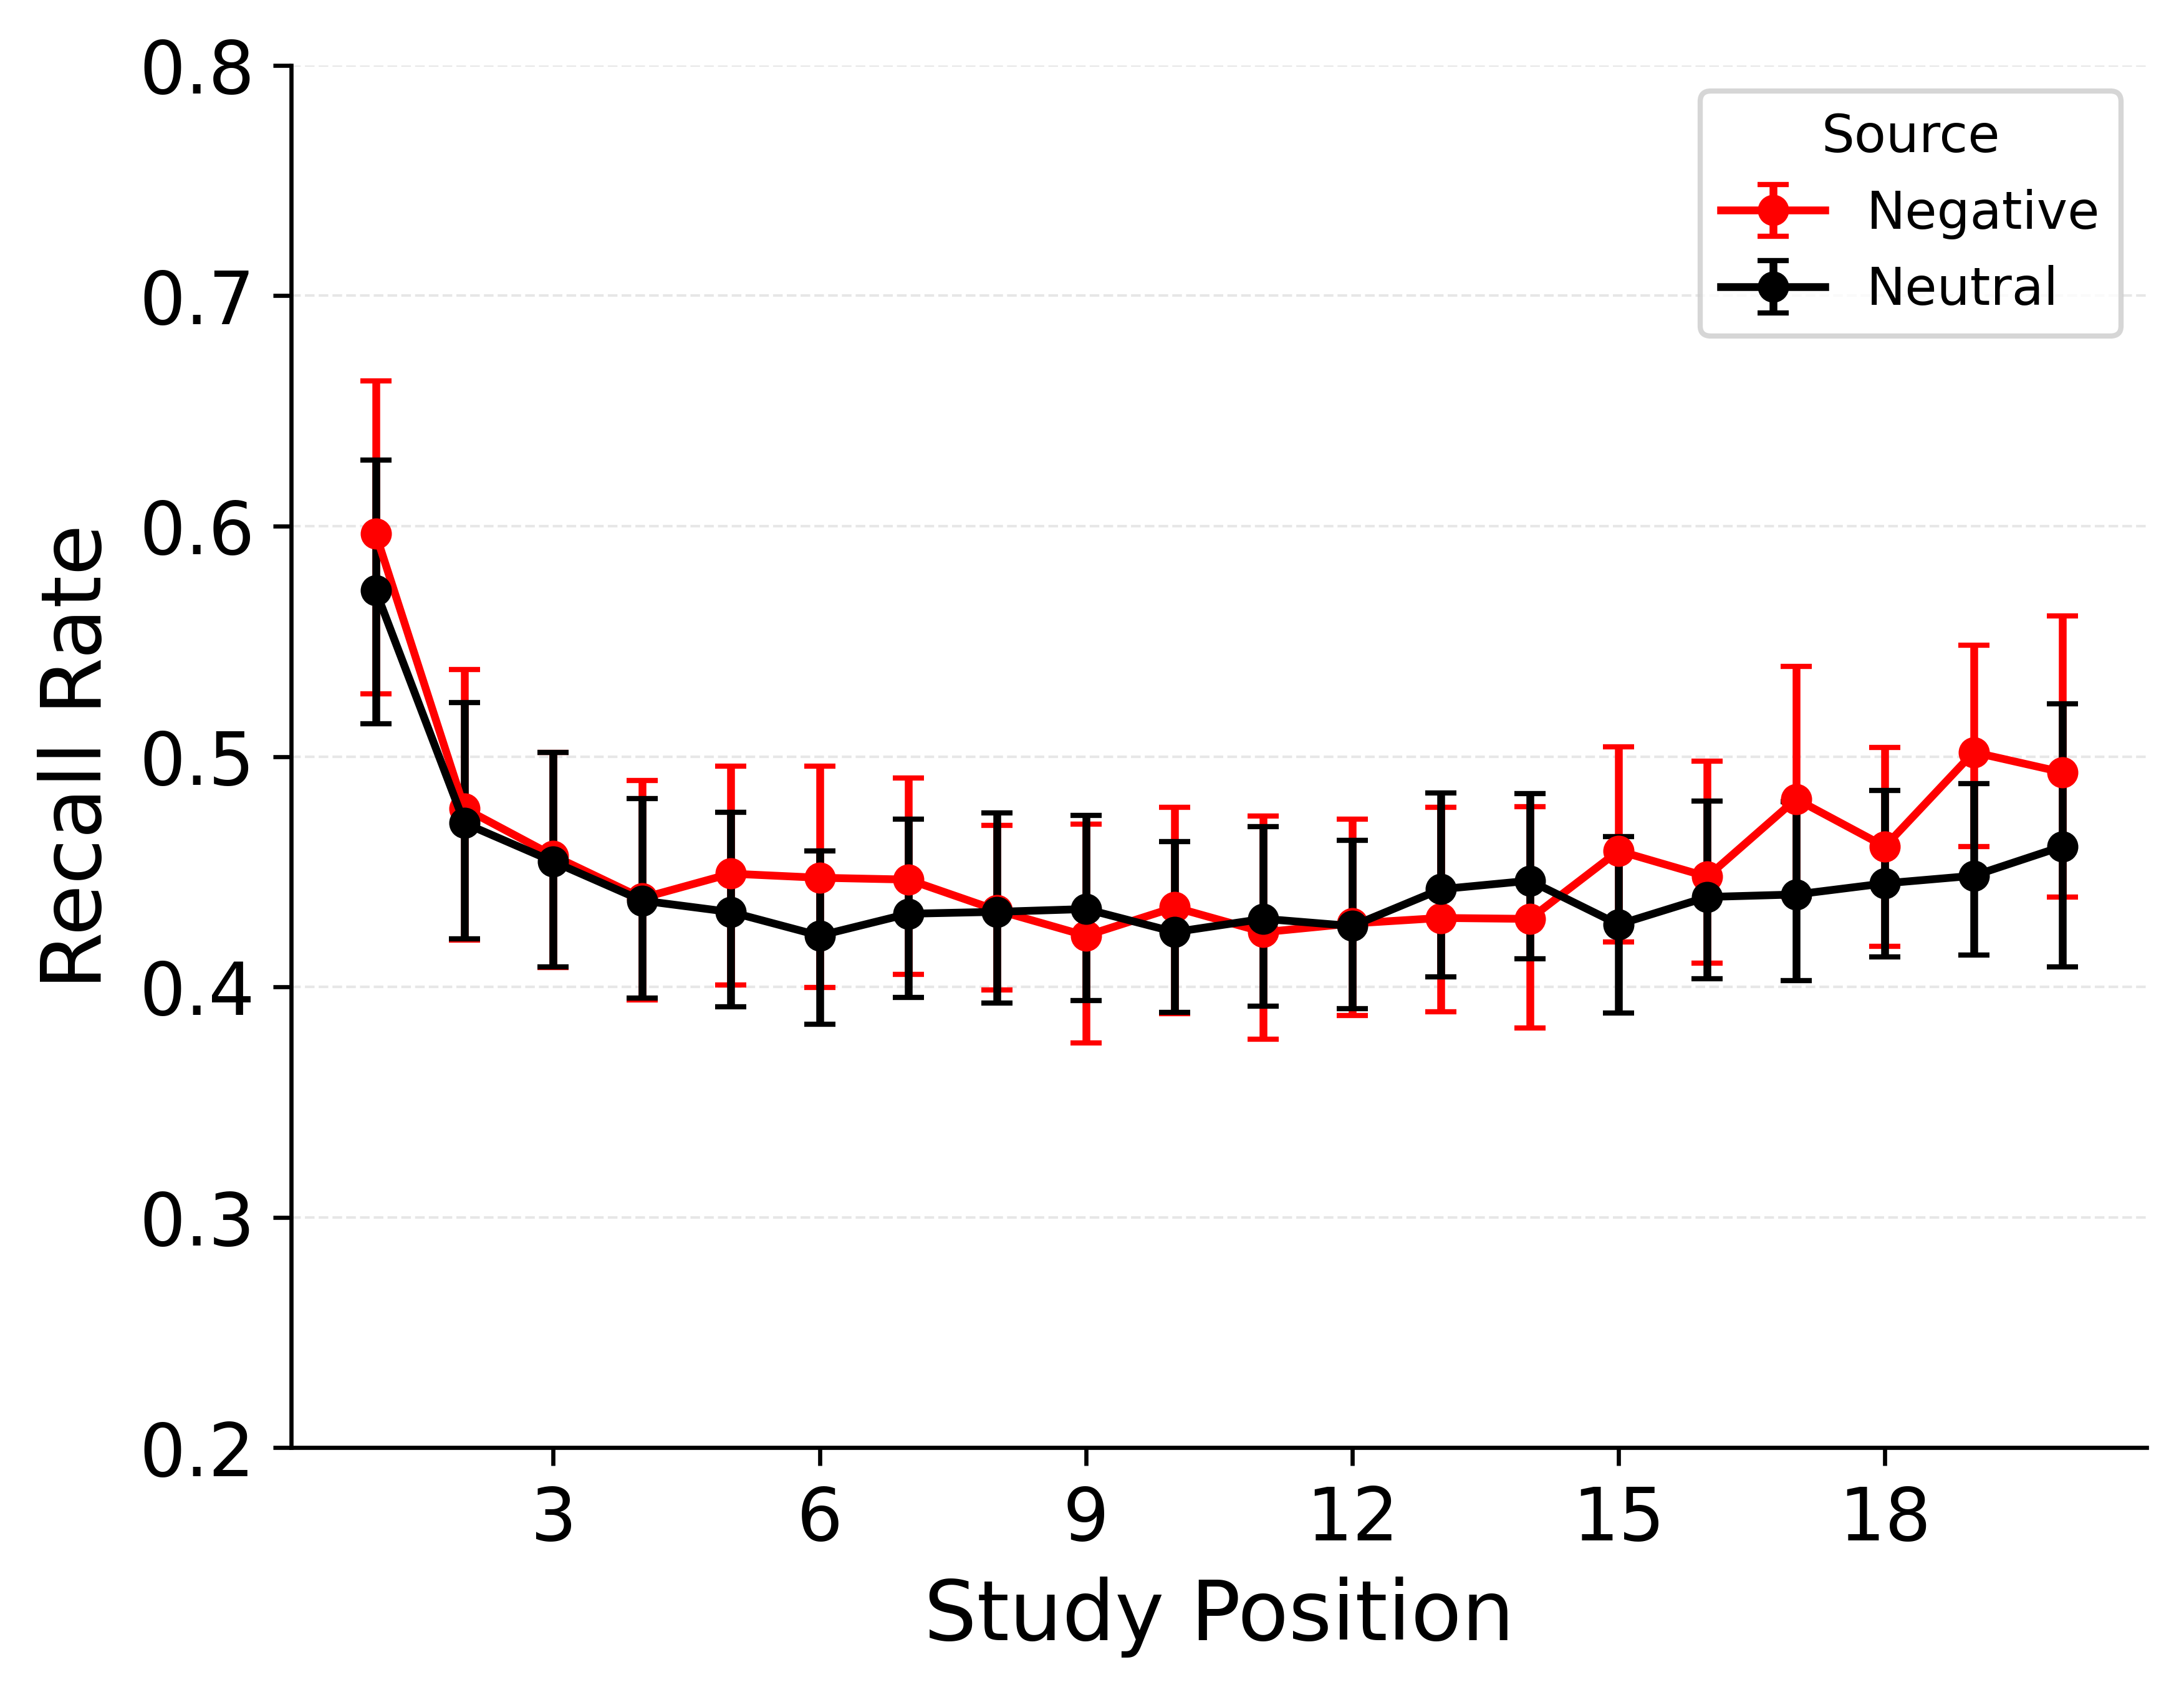

![](/Users/jordangunn/jaxcmr/projects/TalmiEEG/results/figures/fitting/TalmiEEG_EEGLPPParsimonious_50_set_likelihood_fixed_term_best_of_3_cat_lpp_by_recall_NEGATIVE_EARLYLPP.png)


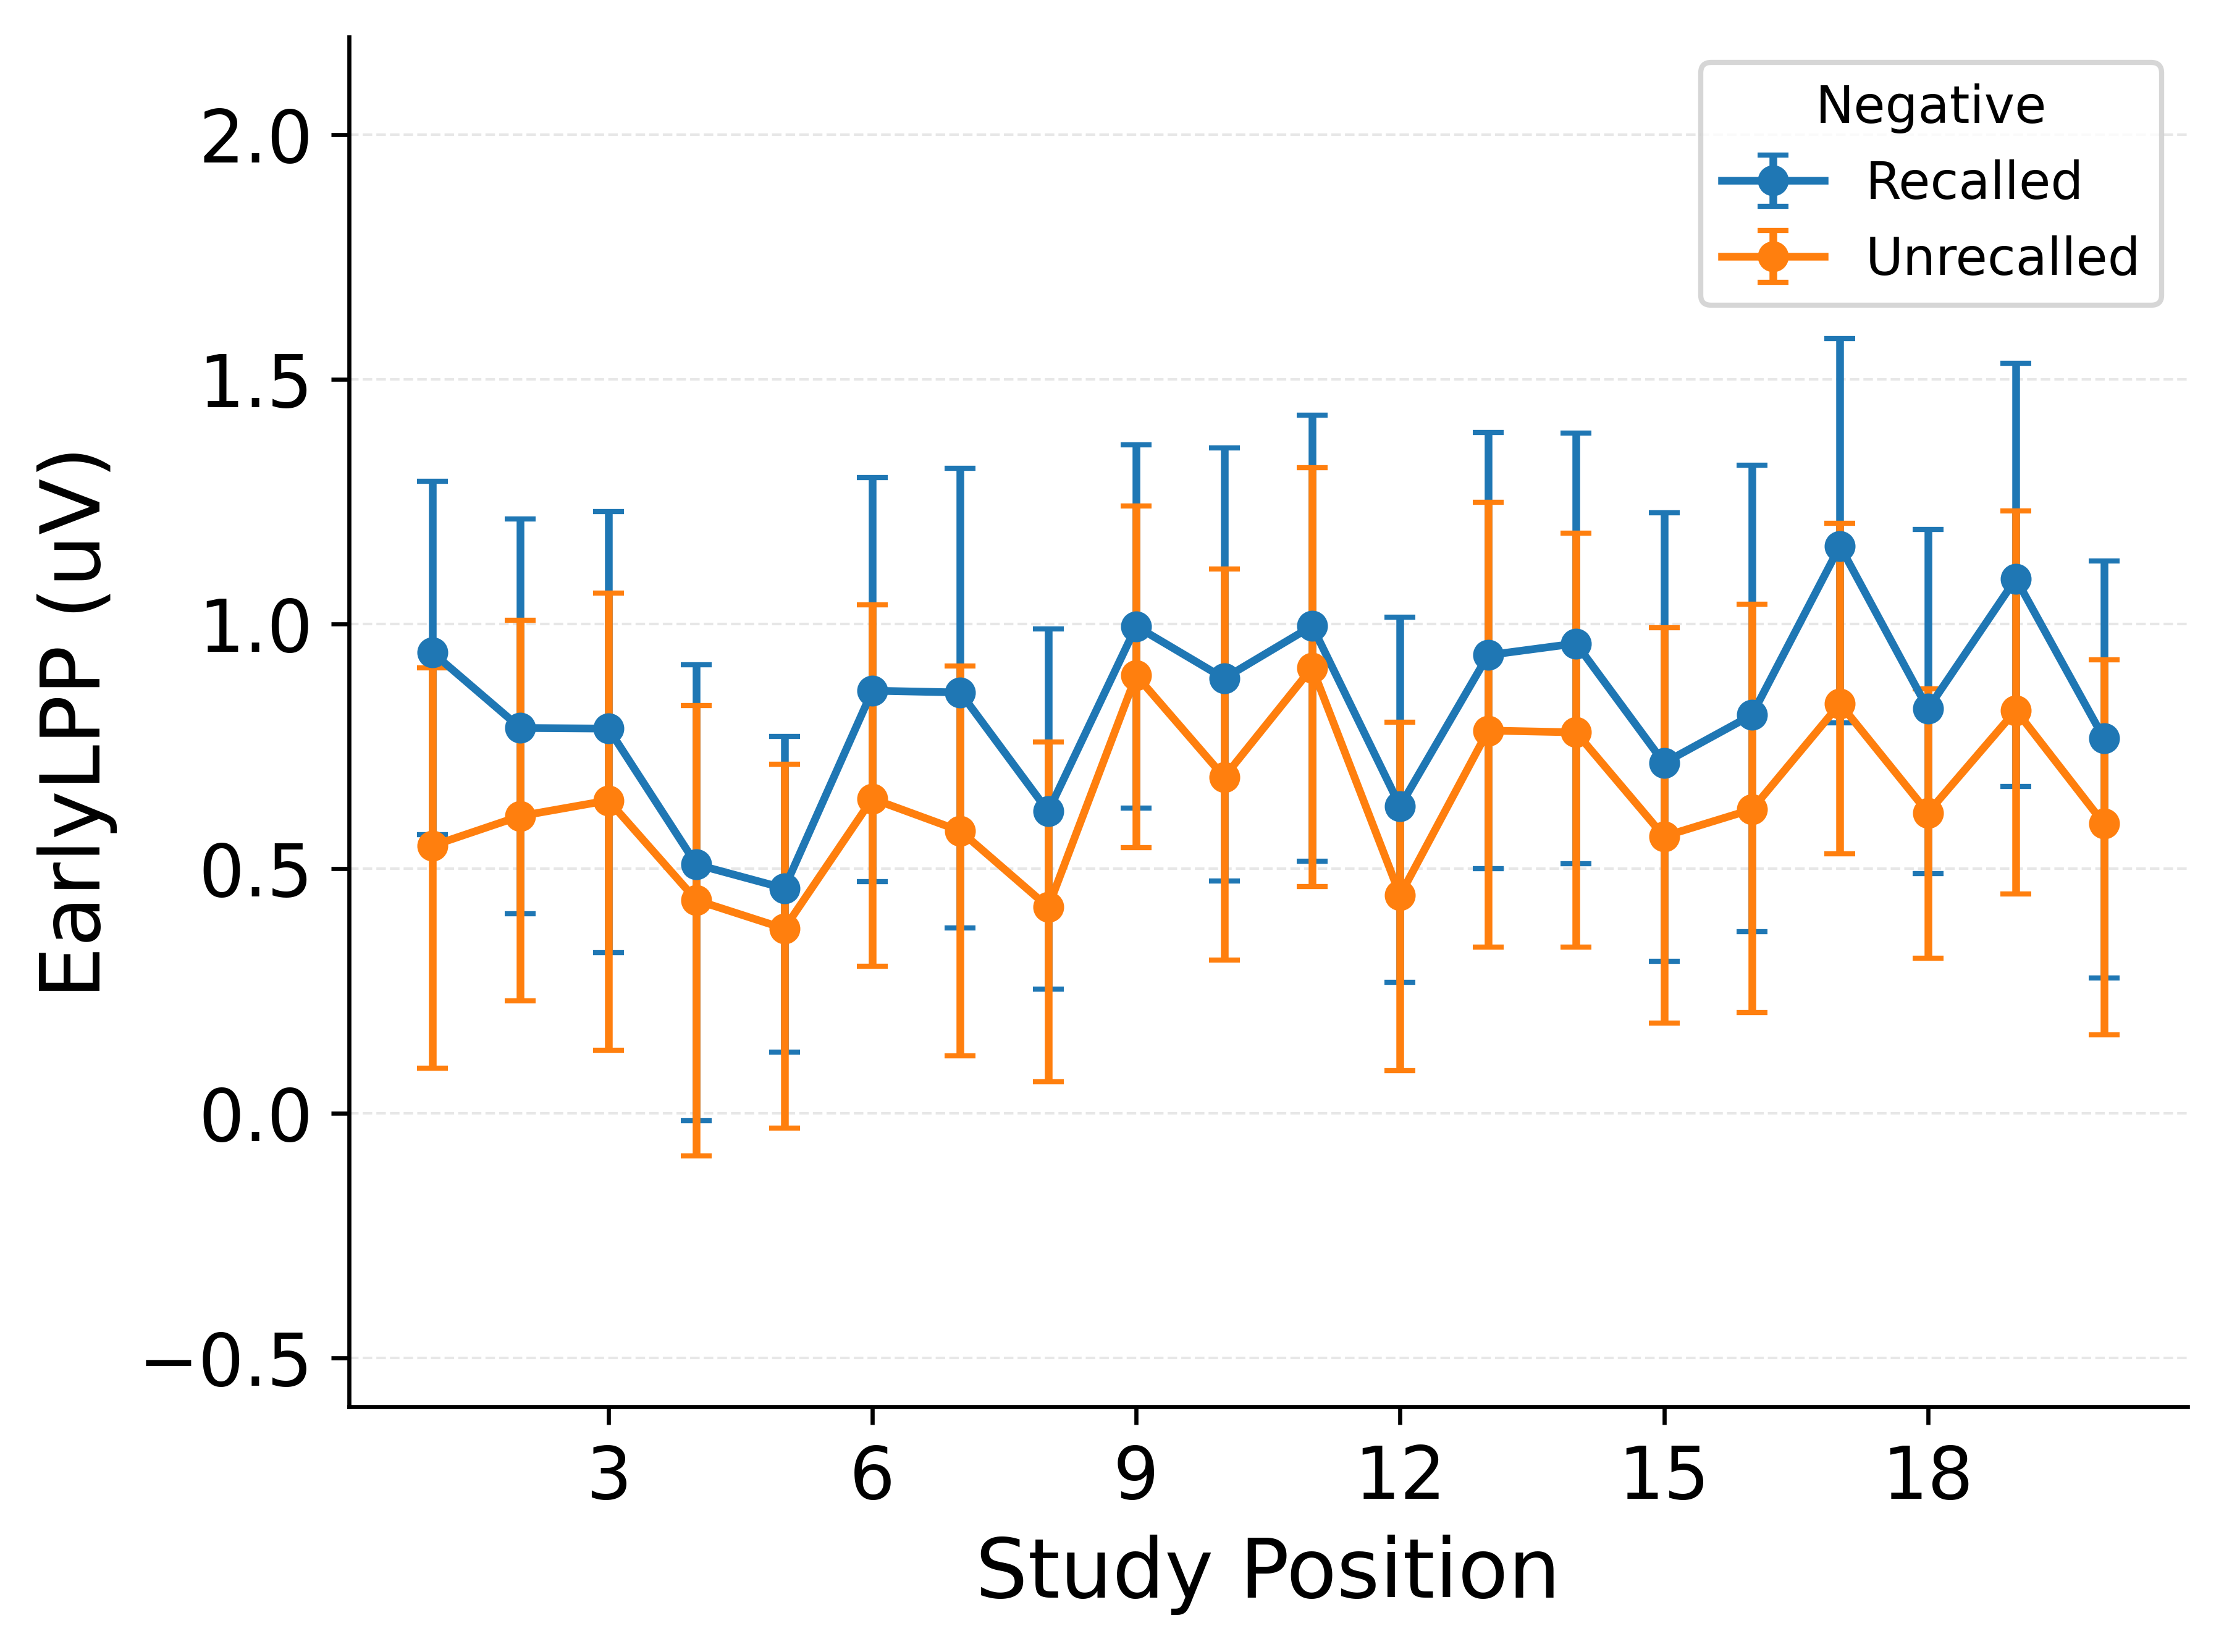

![](/Users/jordangunn/jaxcmr/projects/TalmiEEG/results/figures/fitting/TalmiEEG_EEGLPPParsimonious_50_set_likelihood_fixed_term_best_of_3_cat_lpp_by_recall_NEUTRAL_EARLYLPP.png)


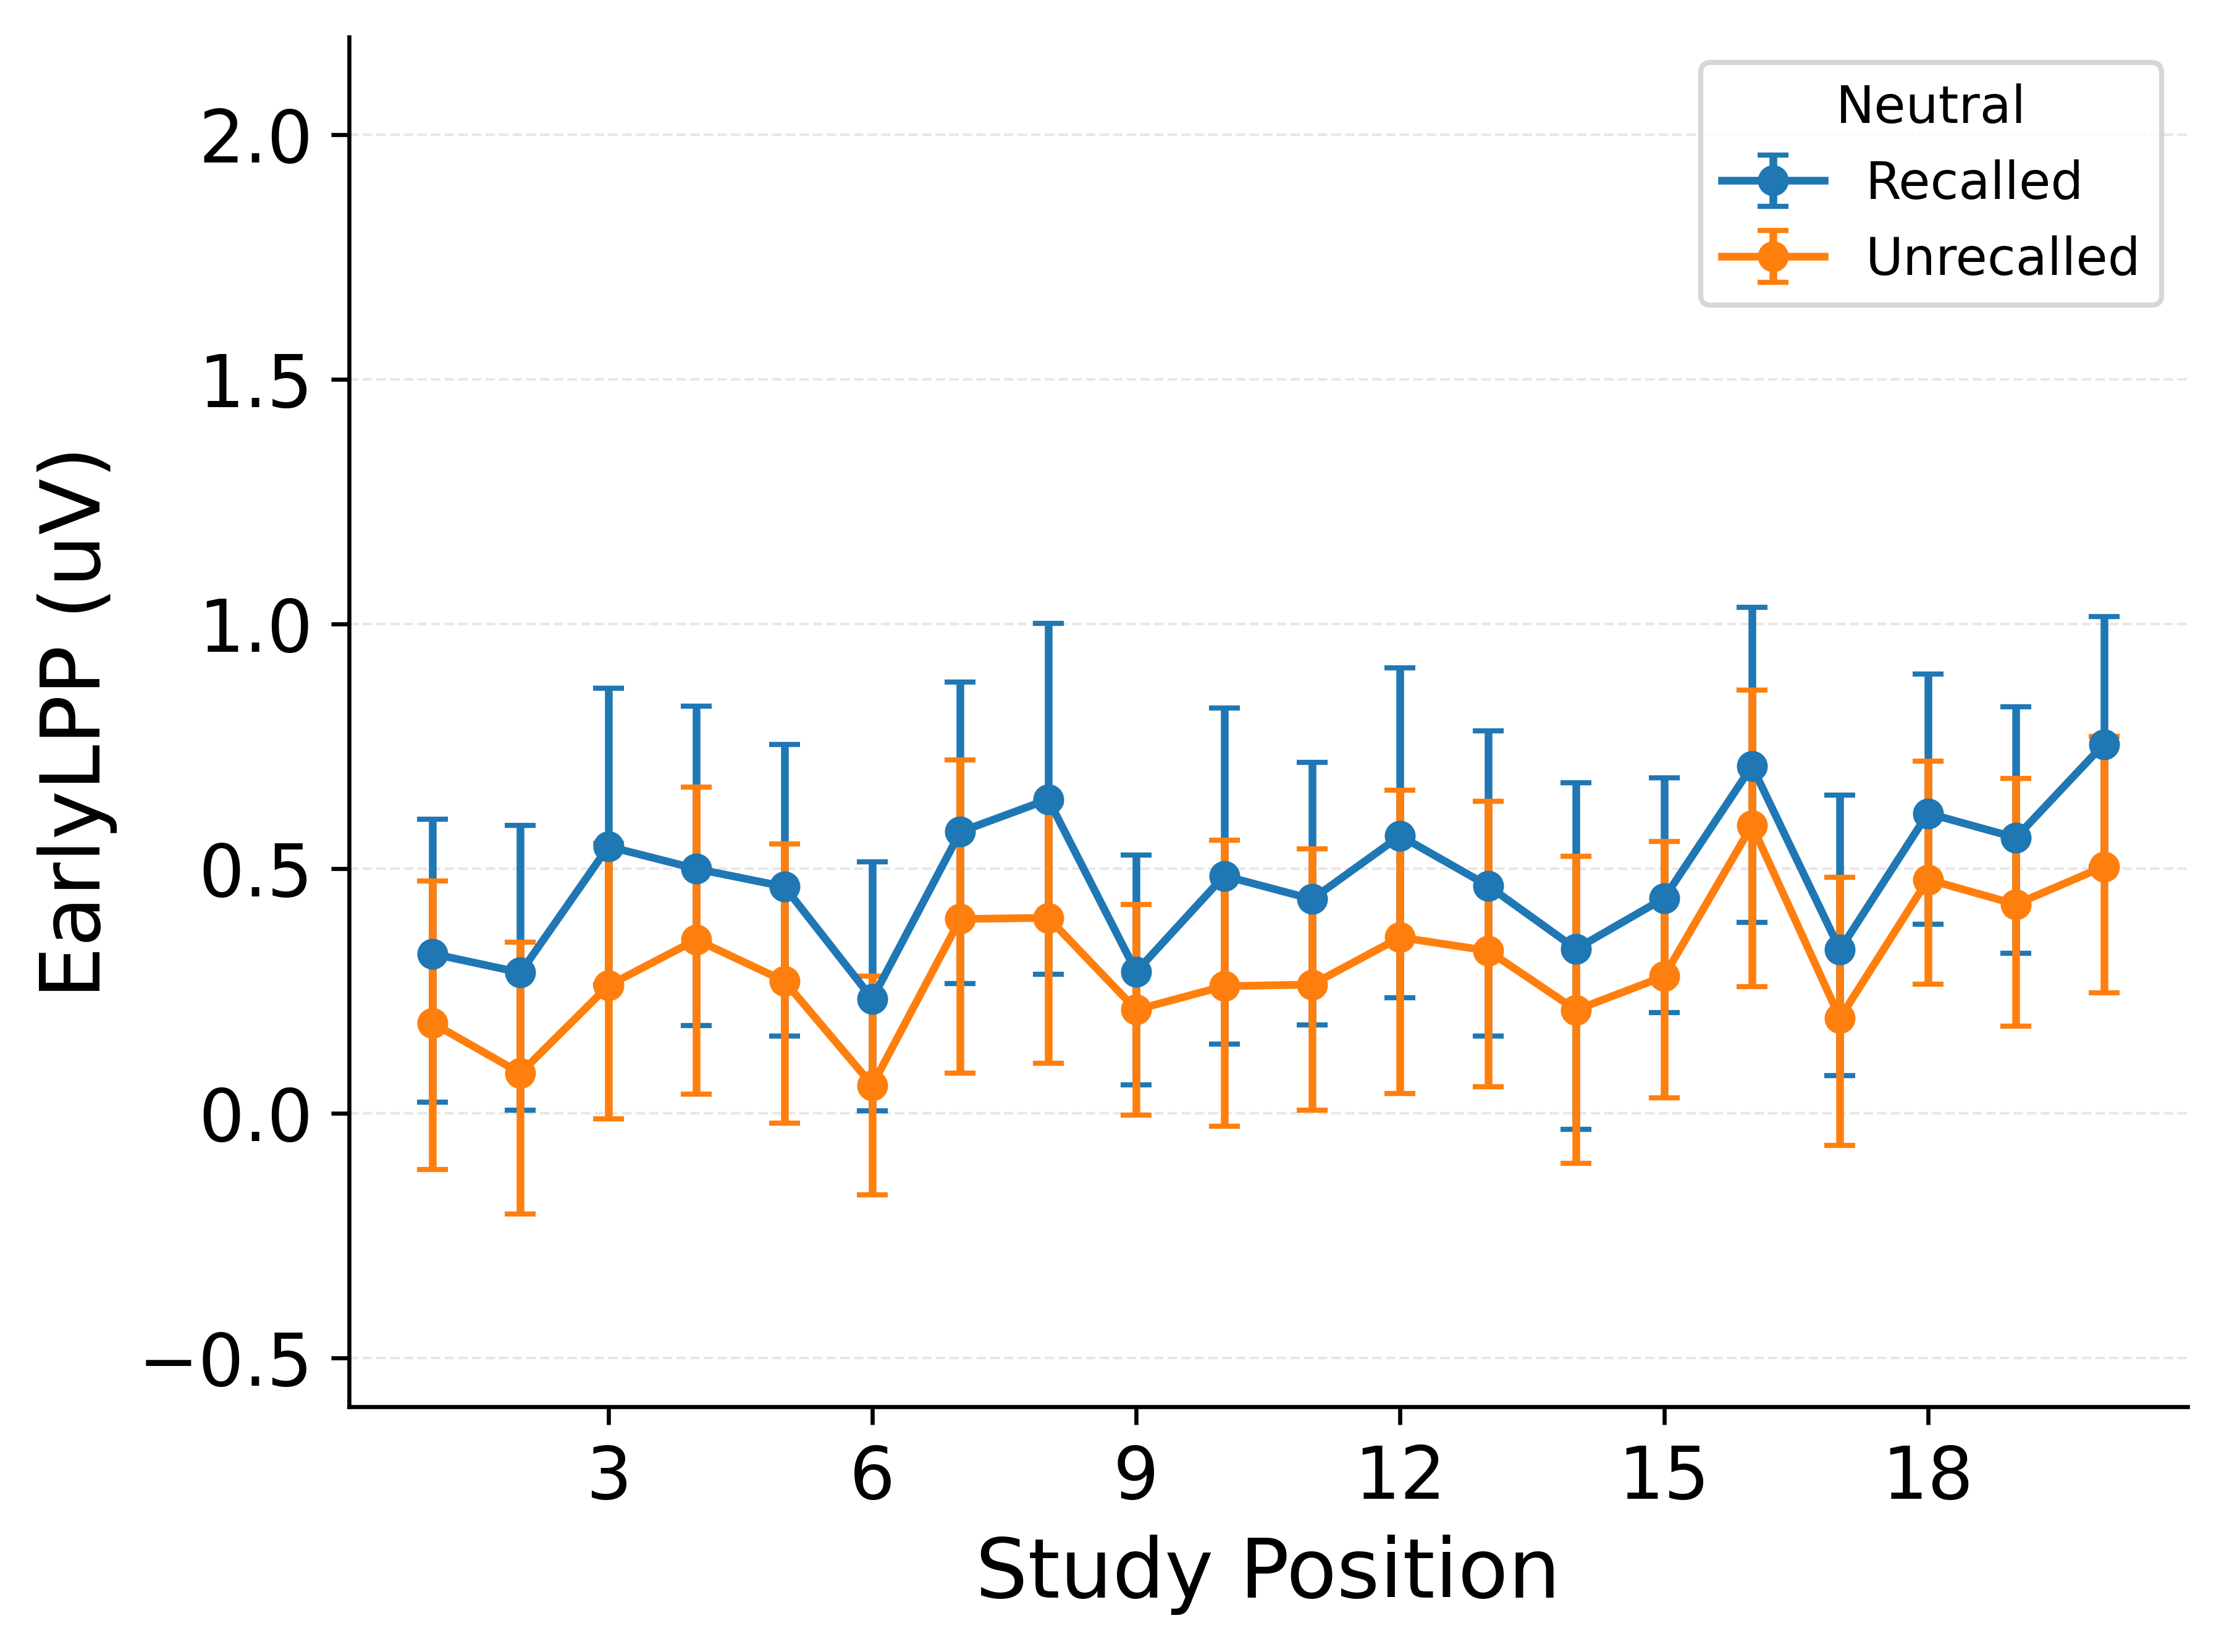

![](/Users/jordangunn/jaxcmr/projects/TalmiEEG/results/figures/fitting/TalmiEEG_EEGLPPParsimonious_50_set_likelihood_fixed_term_best_of_3_cat_lpp_by_recall.png)


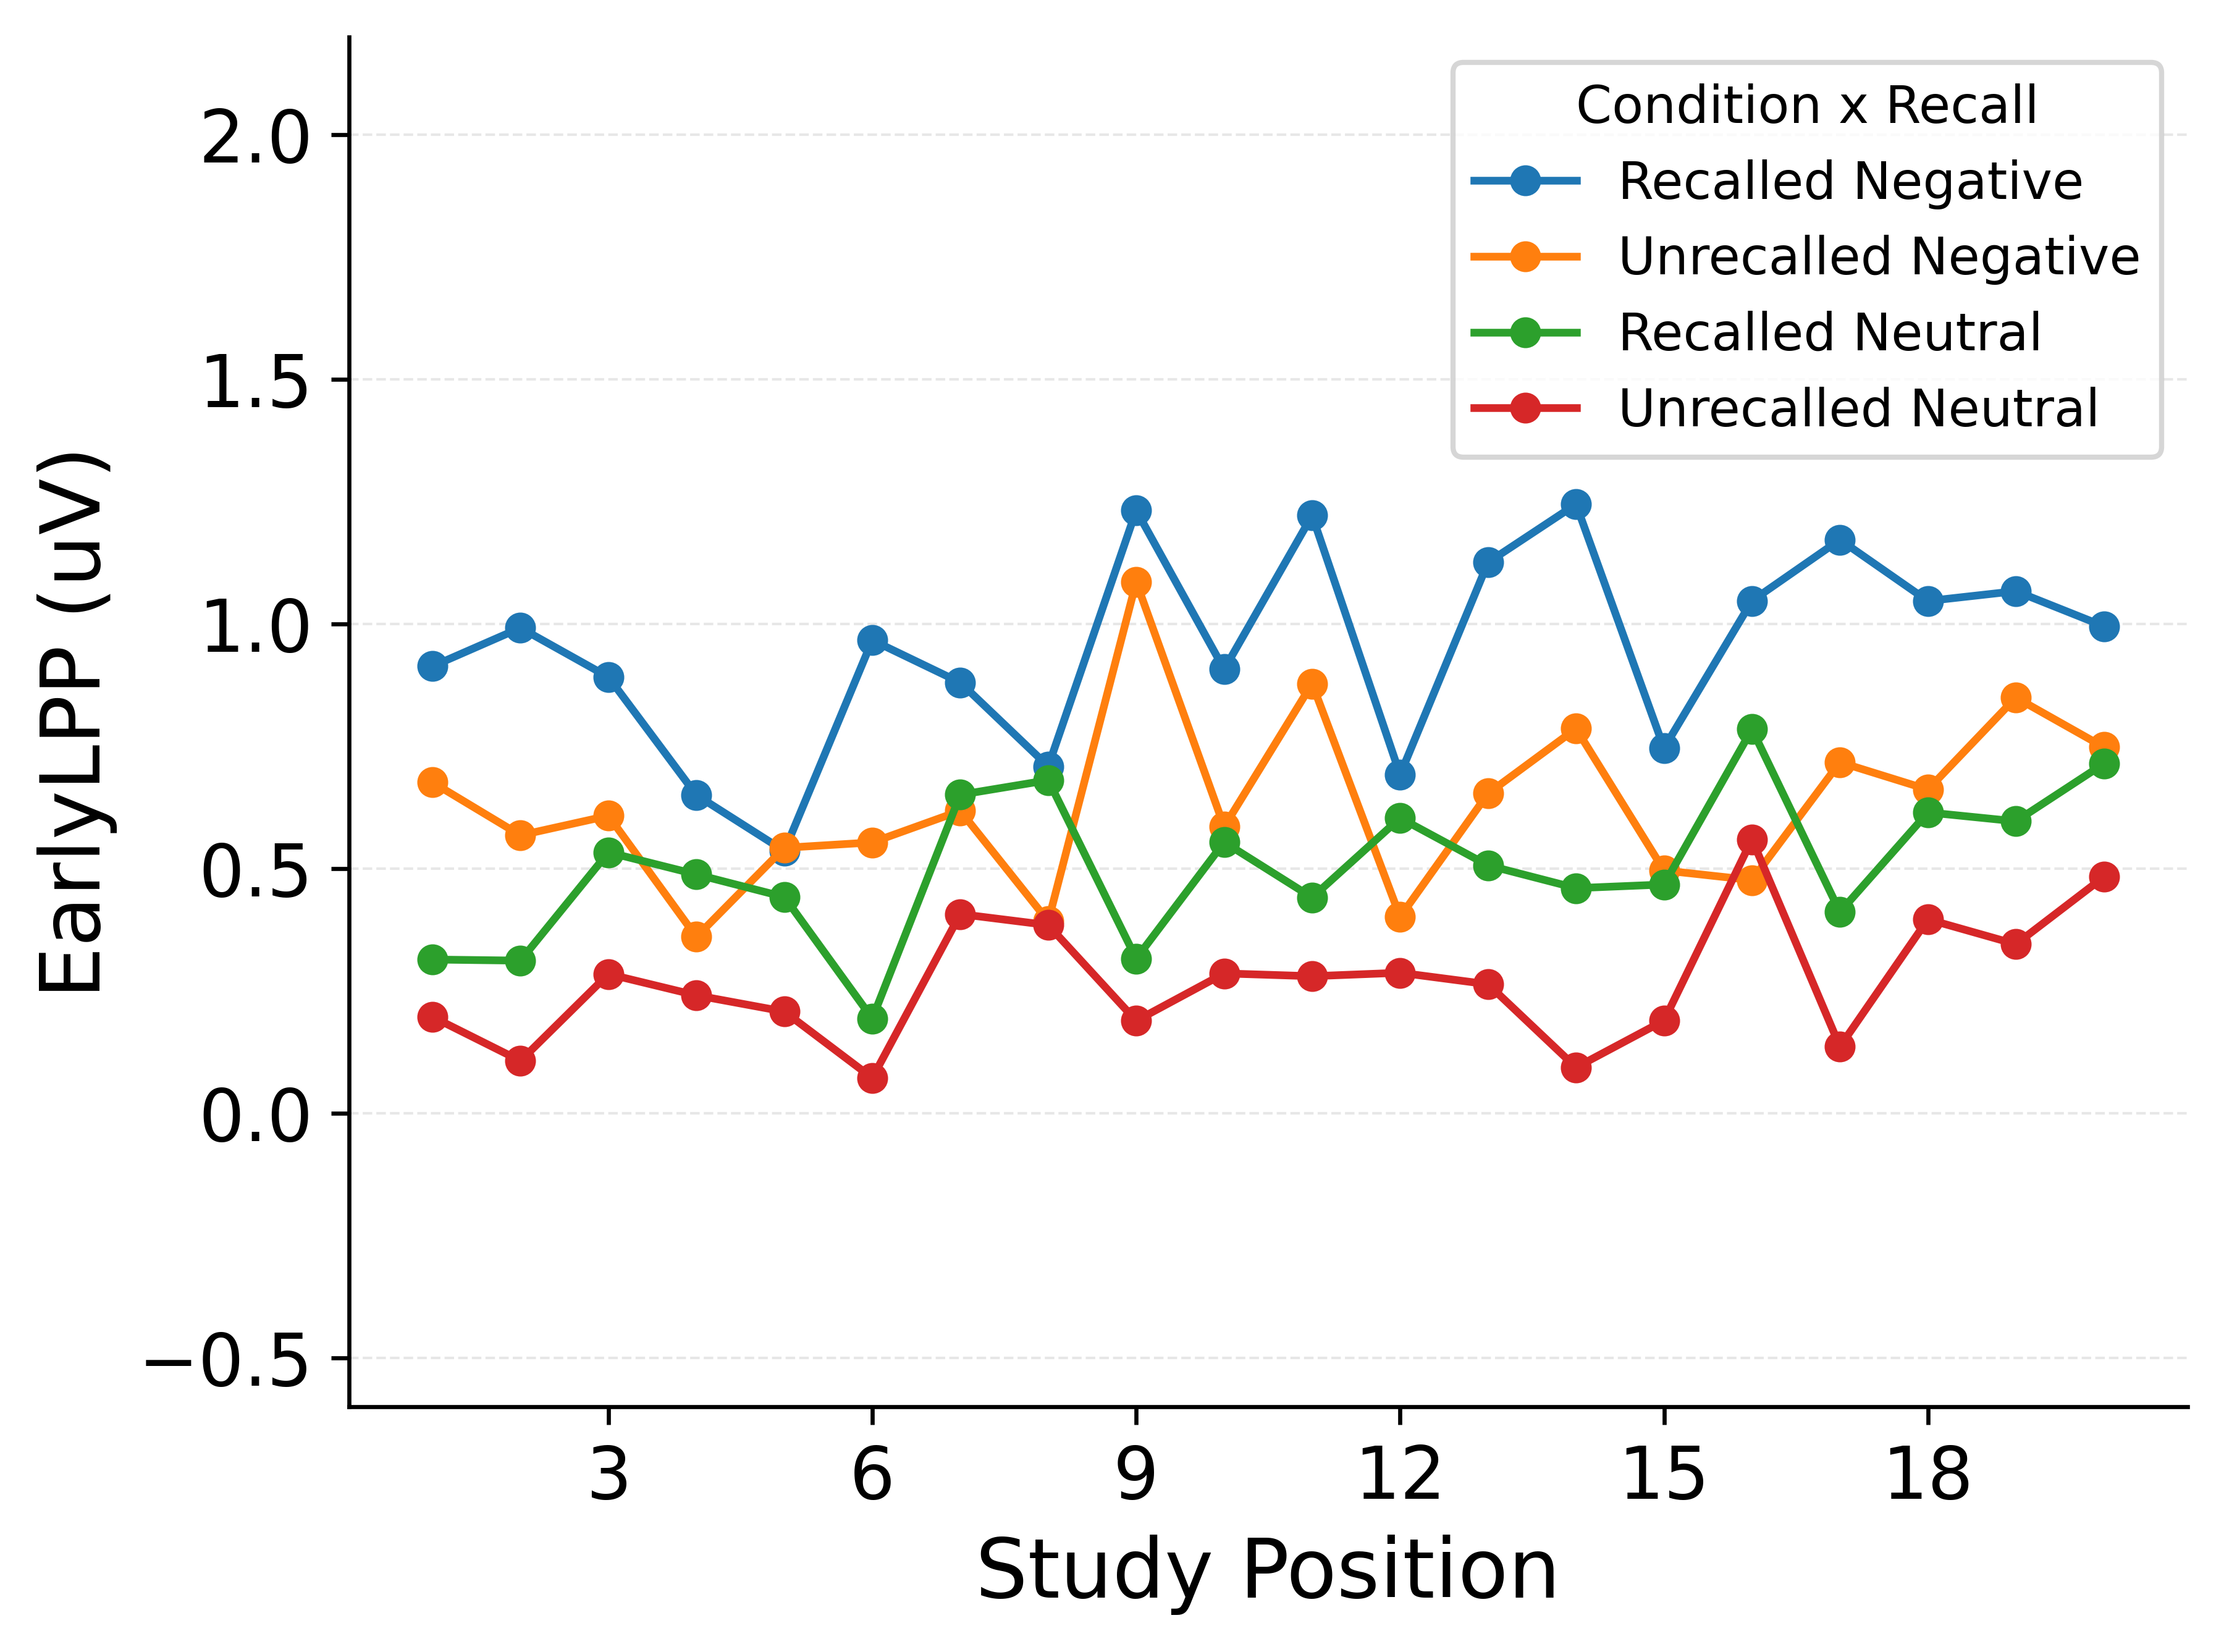

![](/Users/jordangunn/jaxcmr/projects/TalmiEEG/results/figures/fitting/TalmiEEG_EEGLPPParsimonious_50_set_likelihood_fixed_term_best_of_3_cat_spc_negative.png)


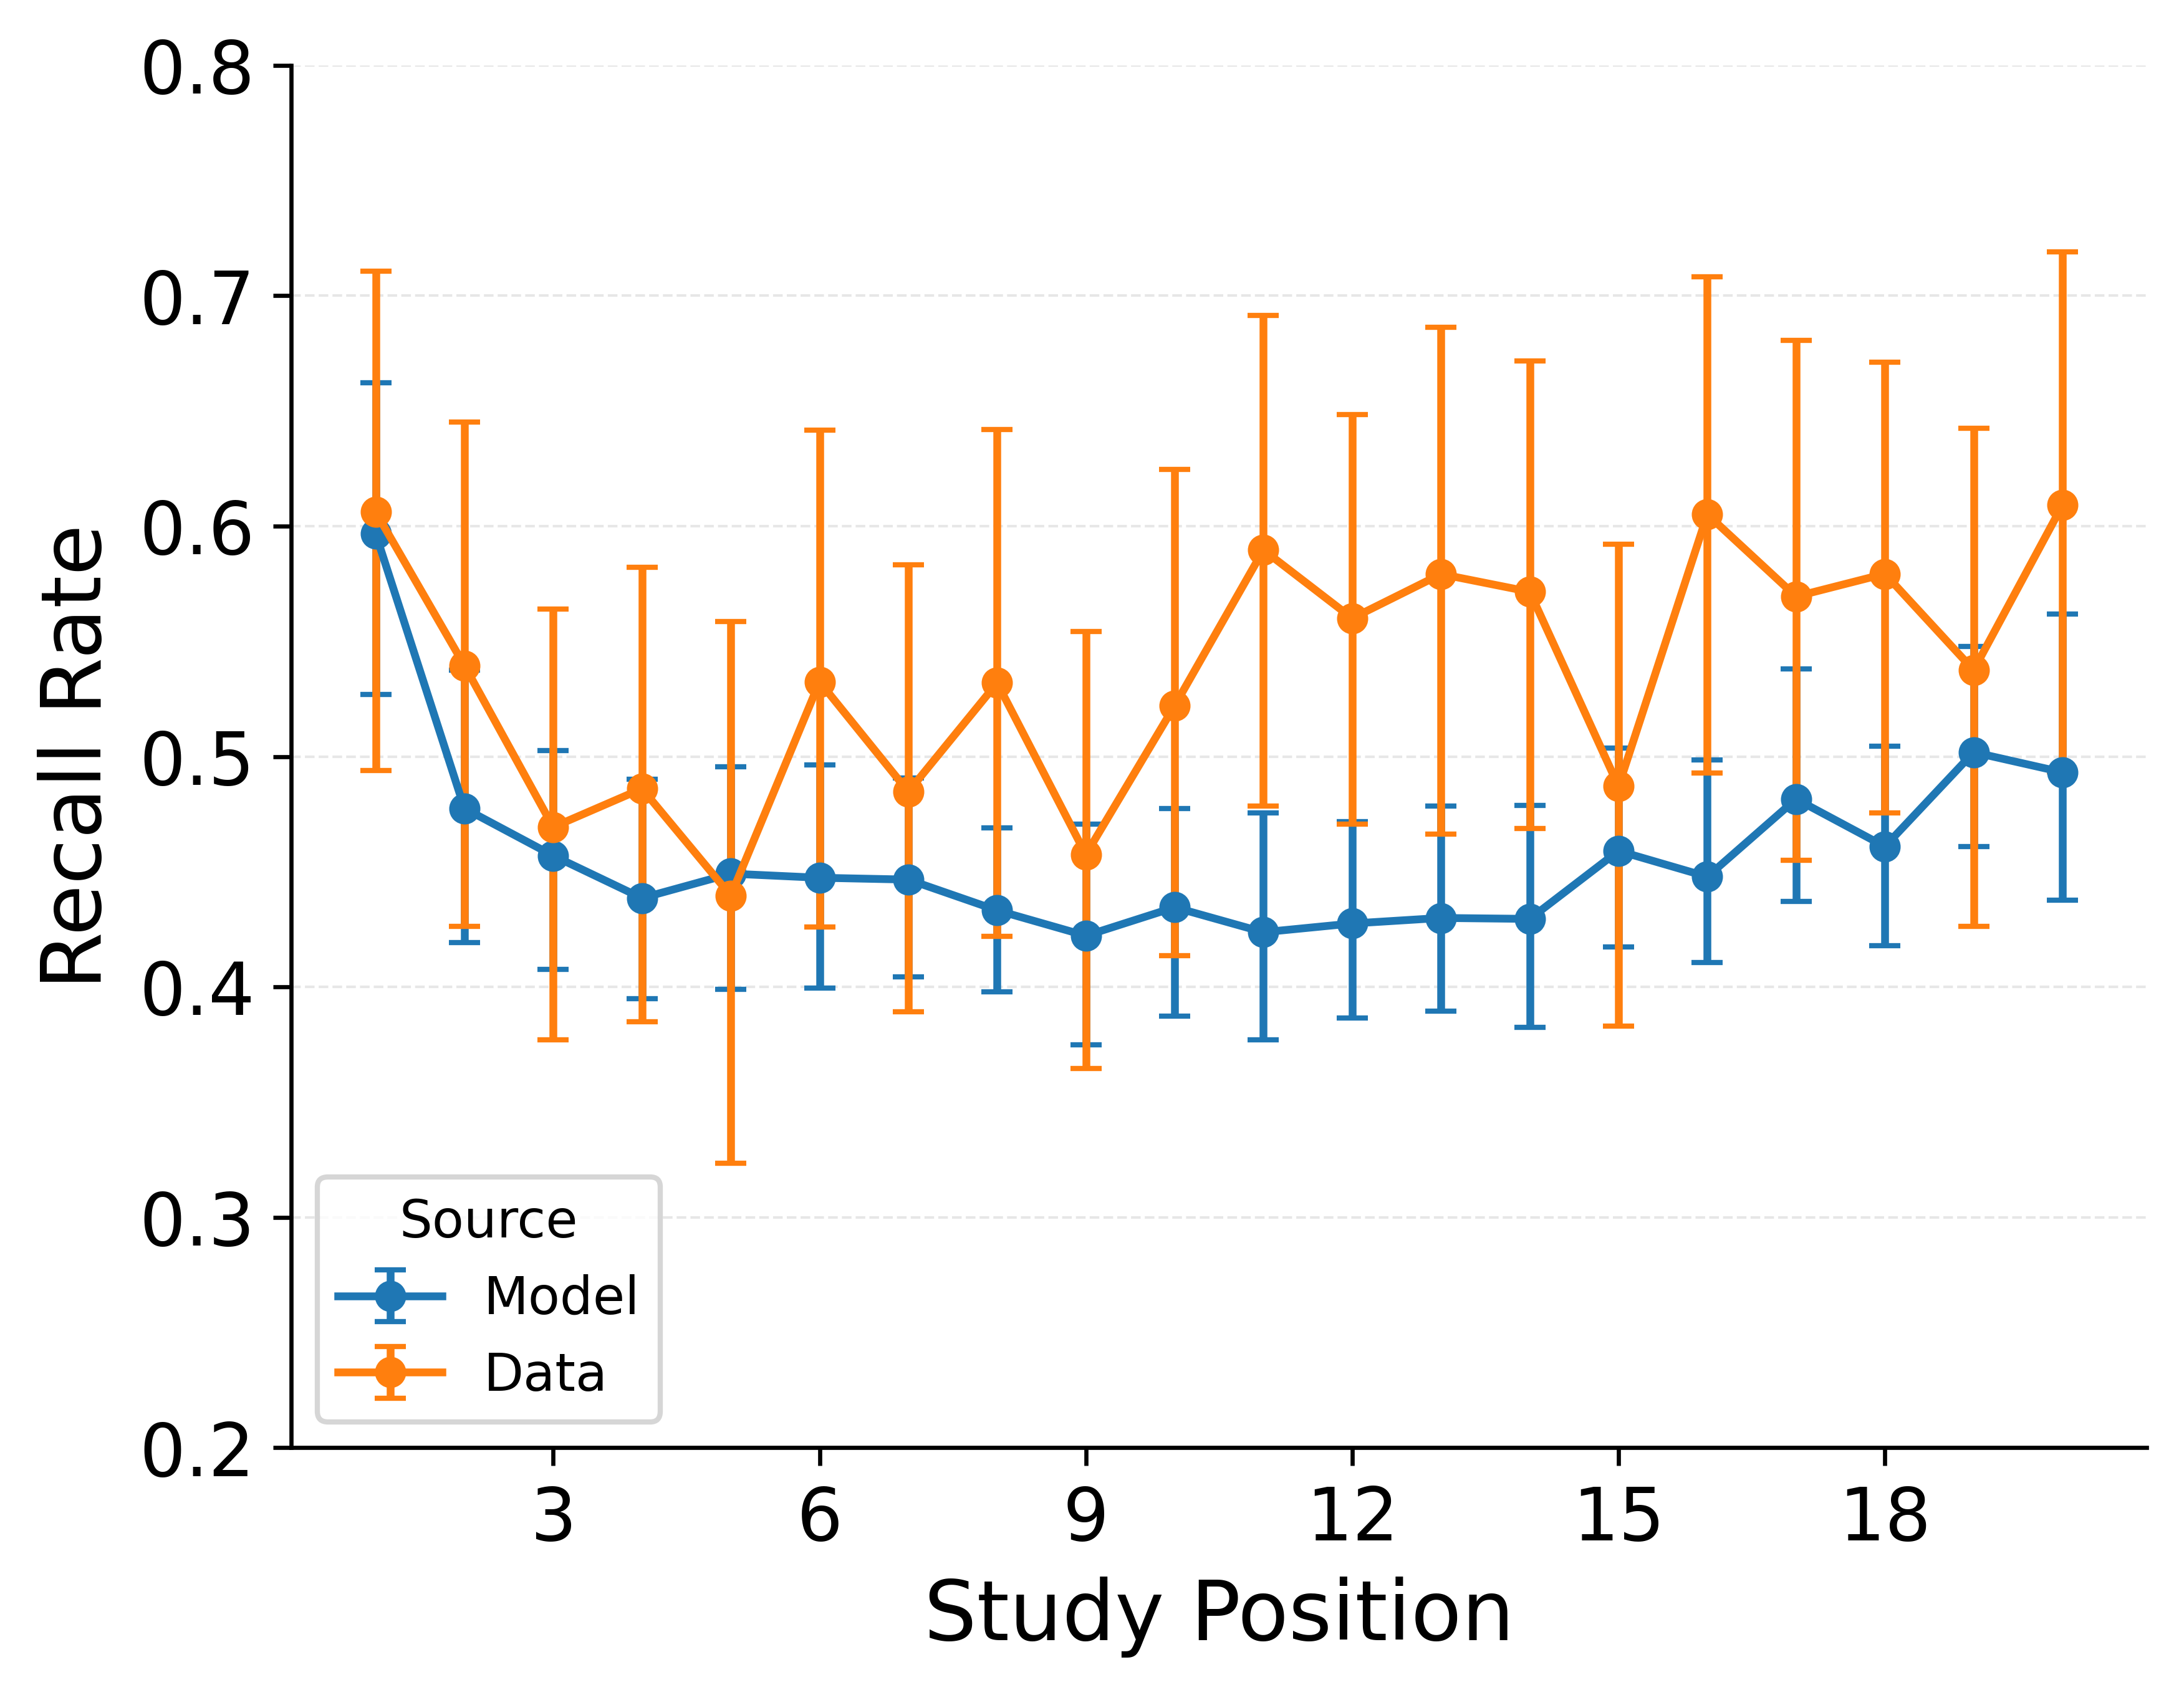

![](/Users/jordangunn/jaxcmr/projects/TalmiEEG/results/figures/fitting/TalmiEEG_EEGLPPParsimonious_50_set_likelihood_fixed_term_best_of_3_cat_spc_neutral.png)


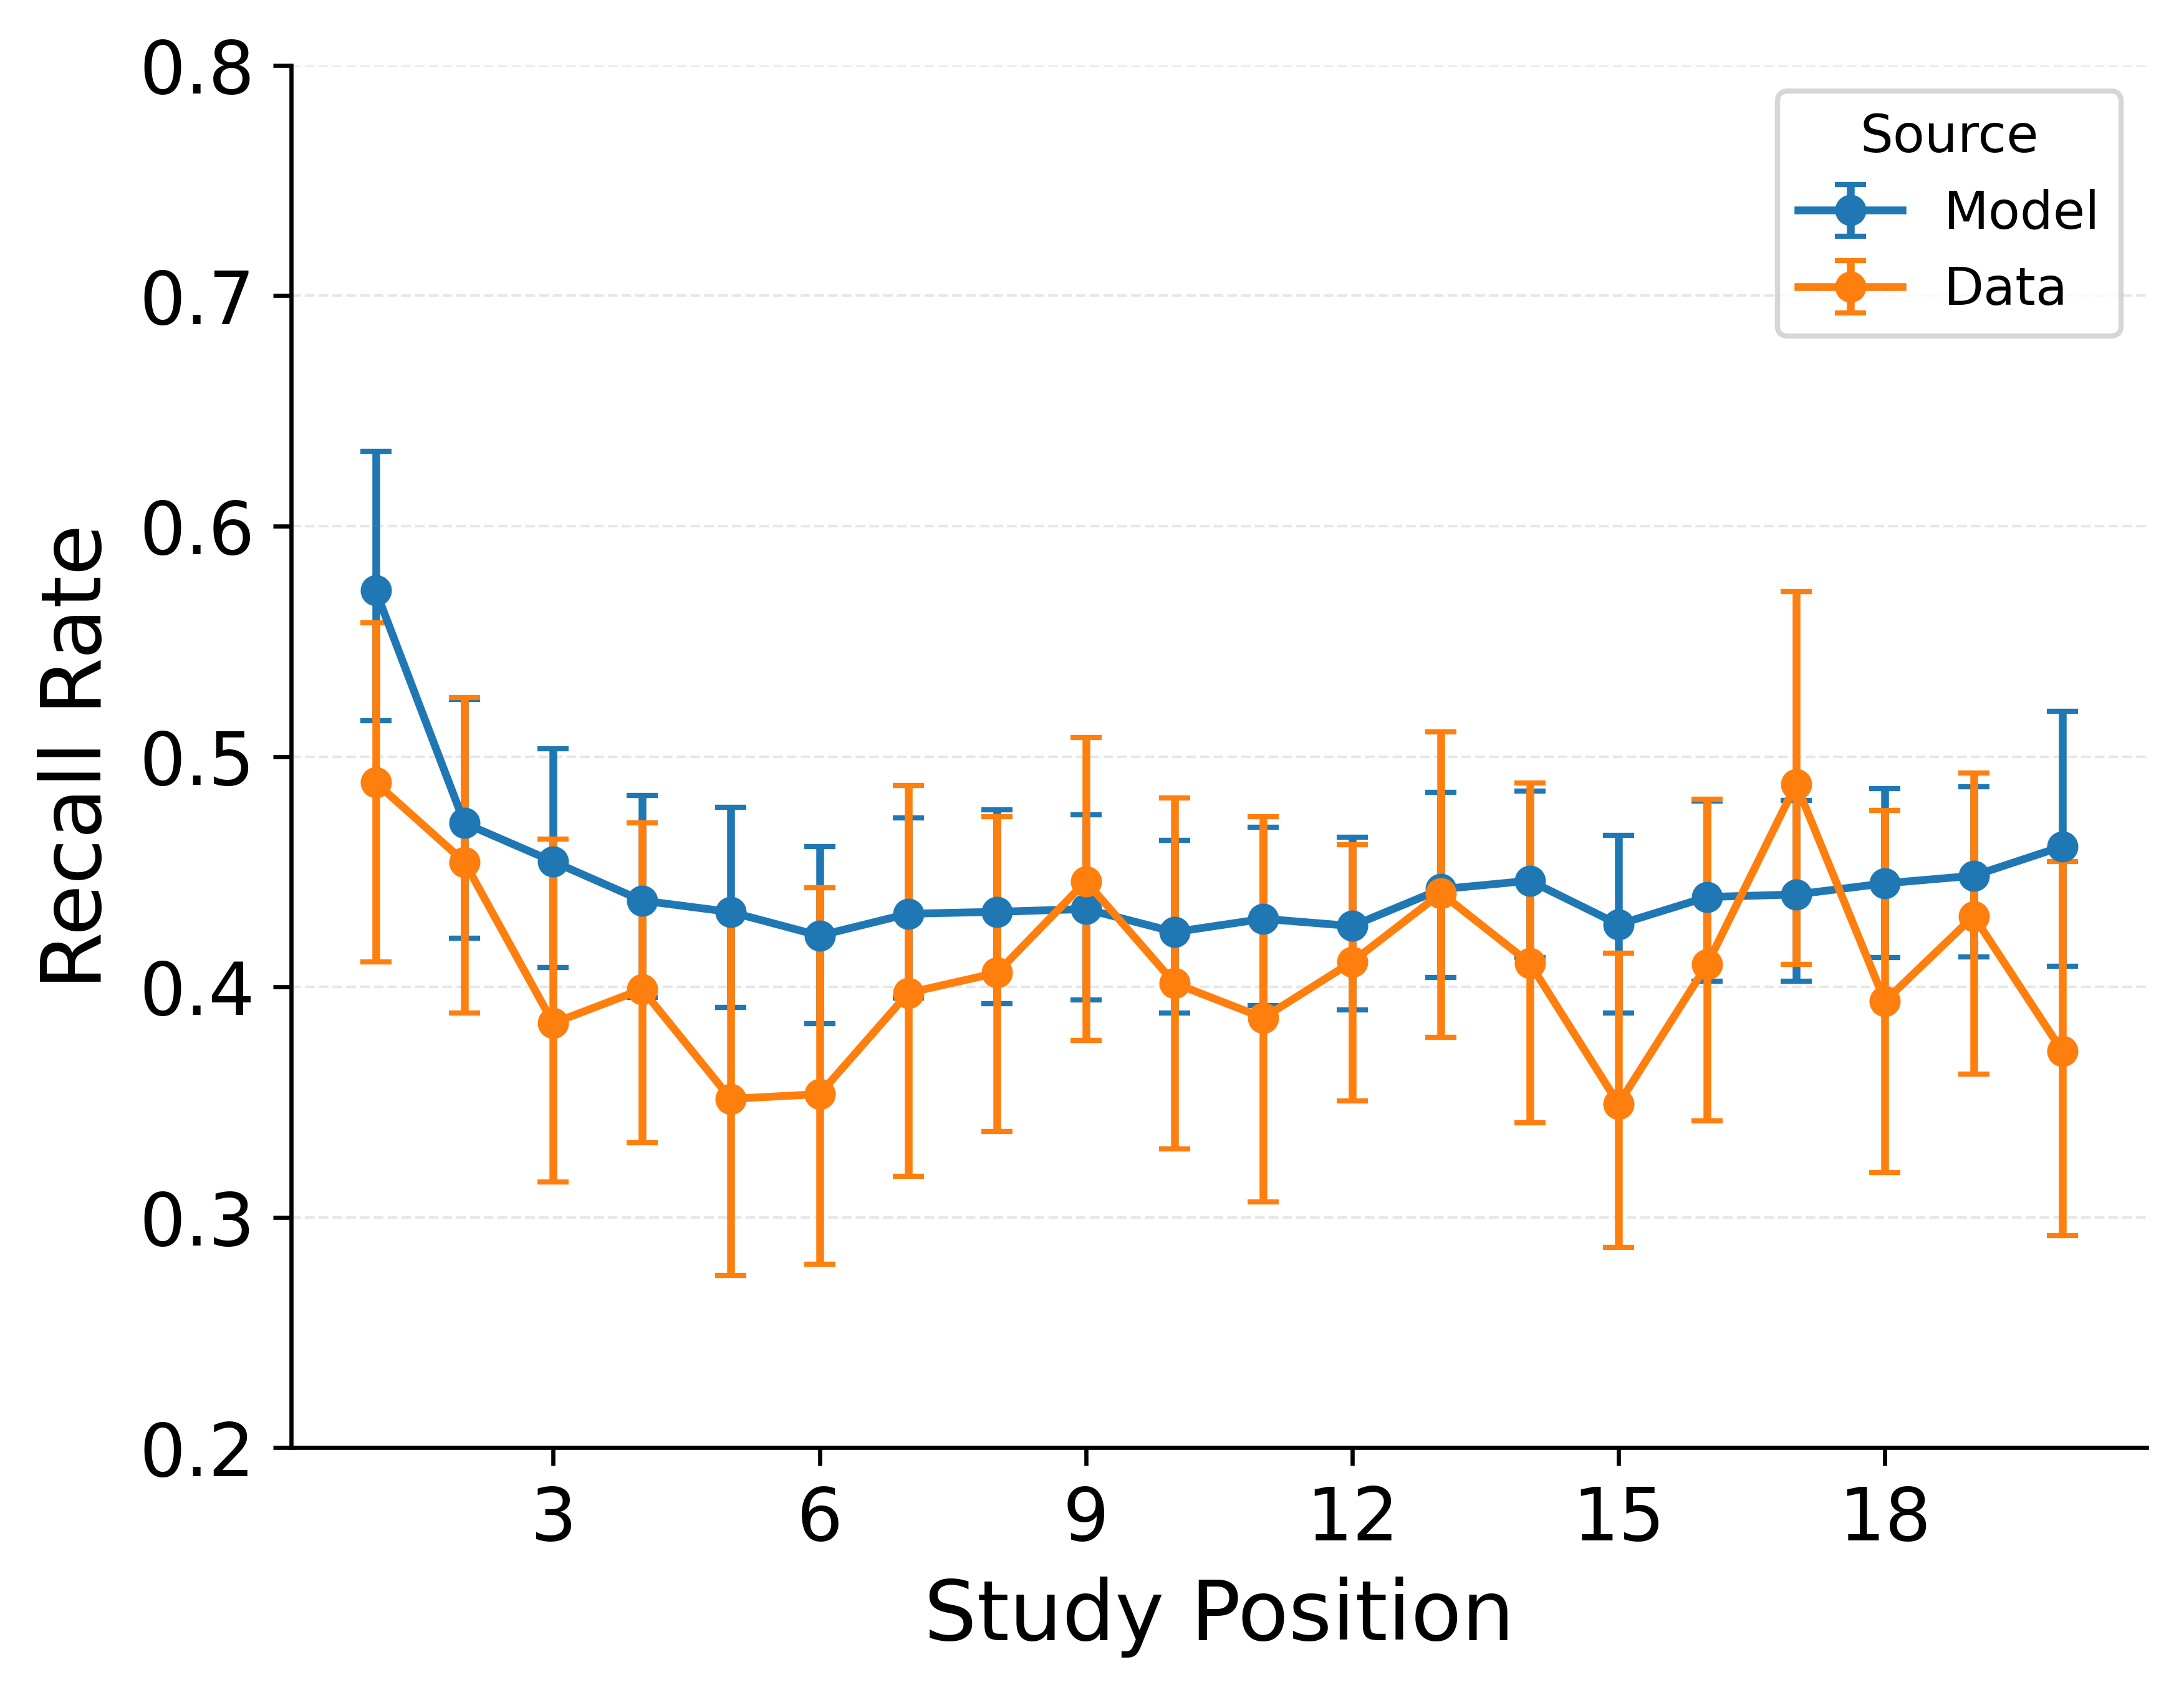

![](/Users/jordangunn/jaxcmr/projects/TalmiEEG/results/figures/fitting/TalmiEEG_EEGLPPParsimonious_50_set_likelihood_fixed_term_best_of_3_spc.png)


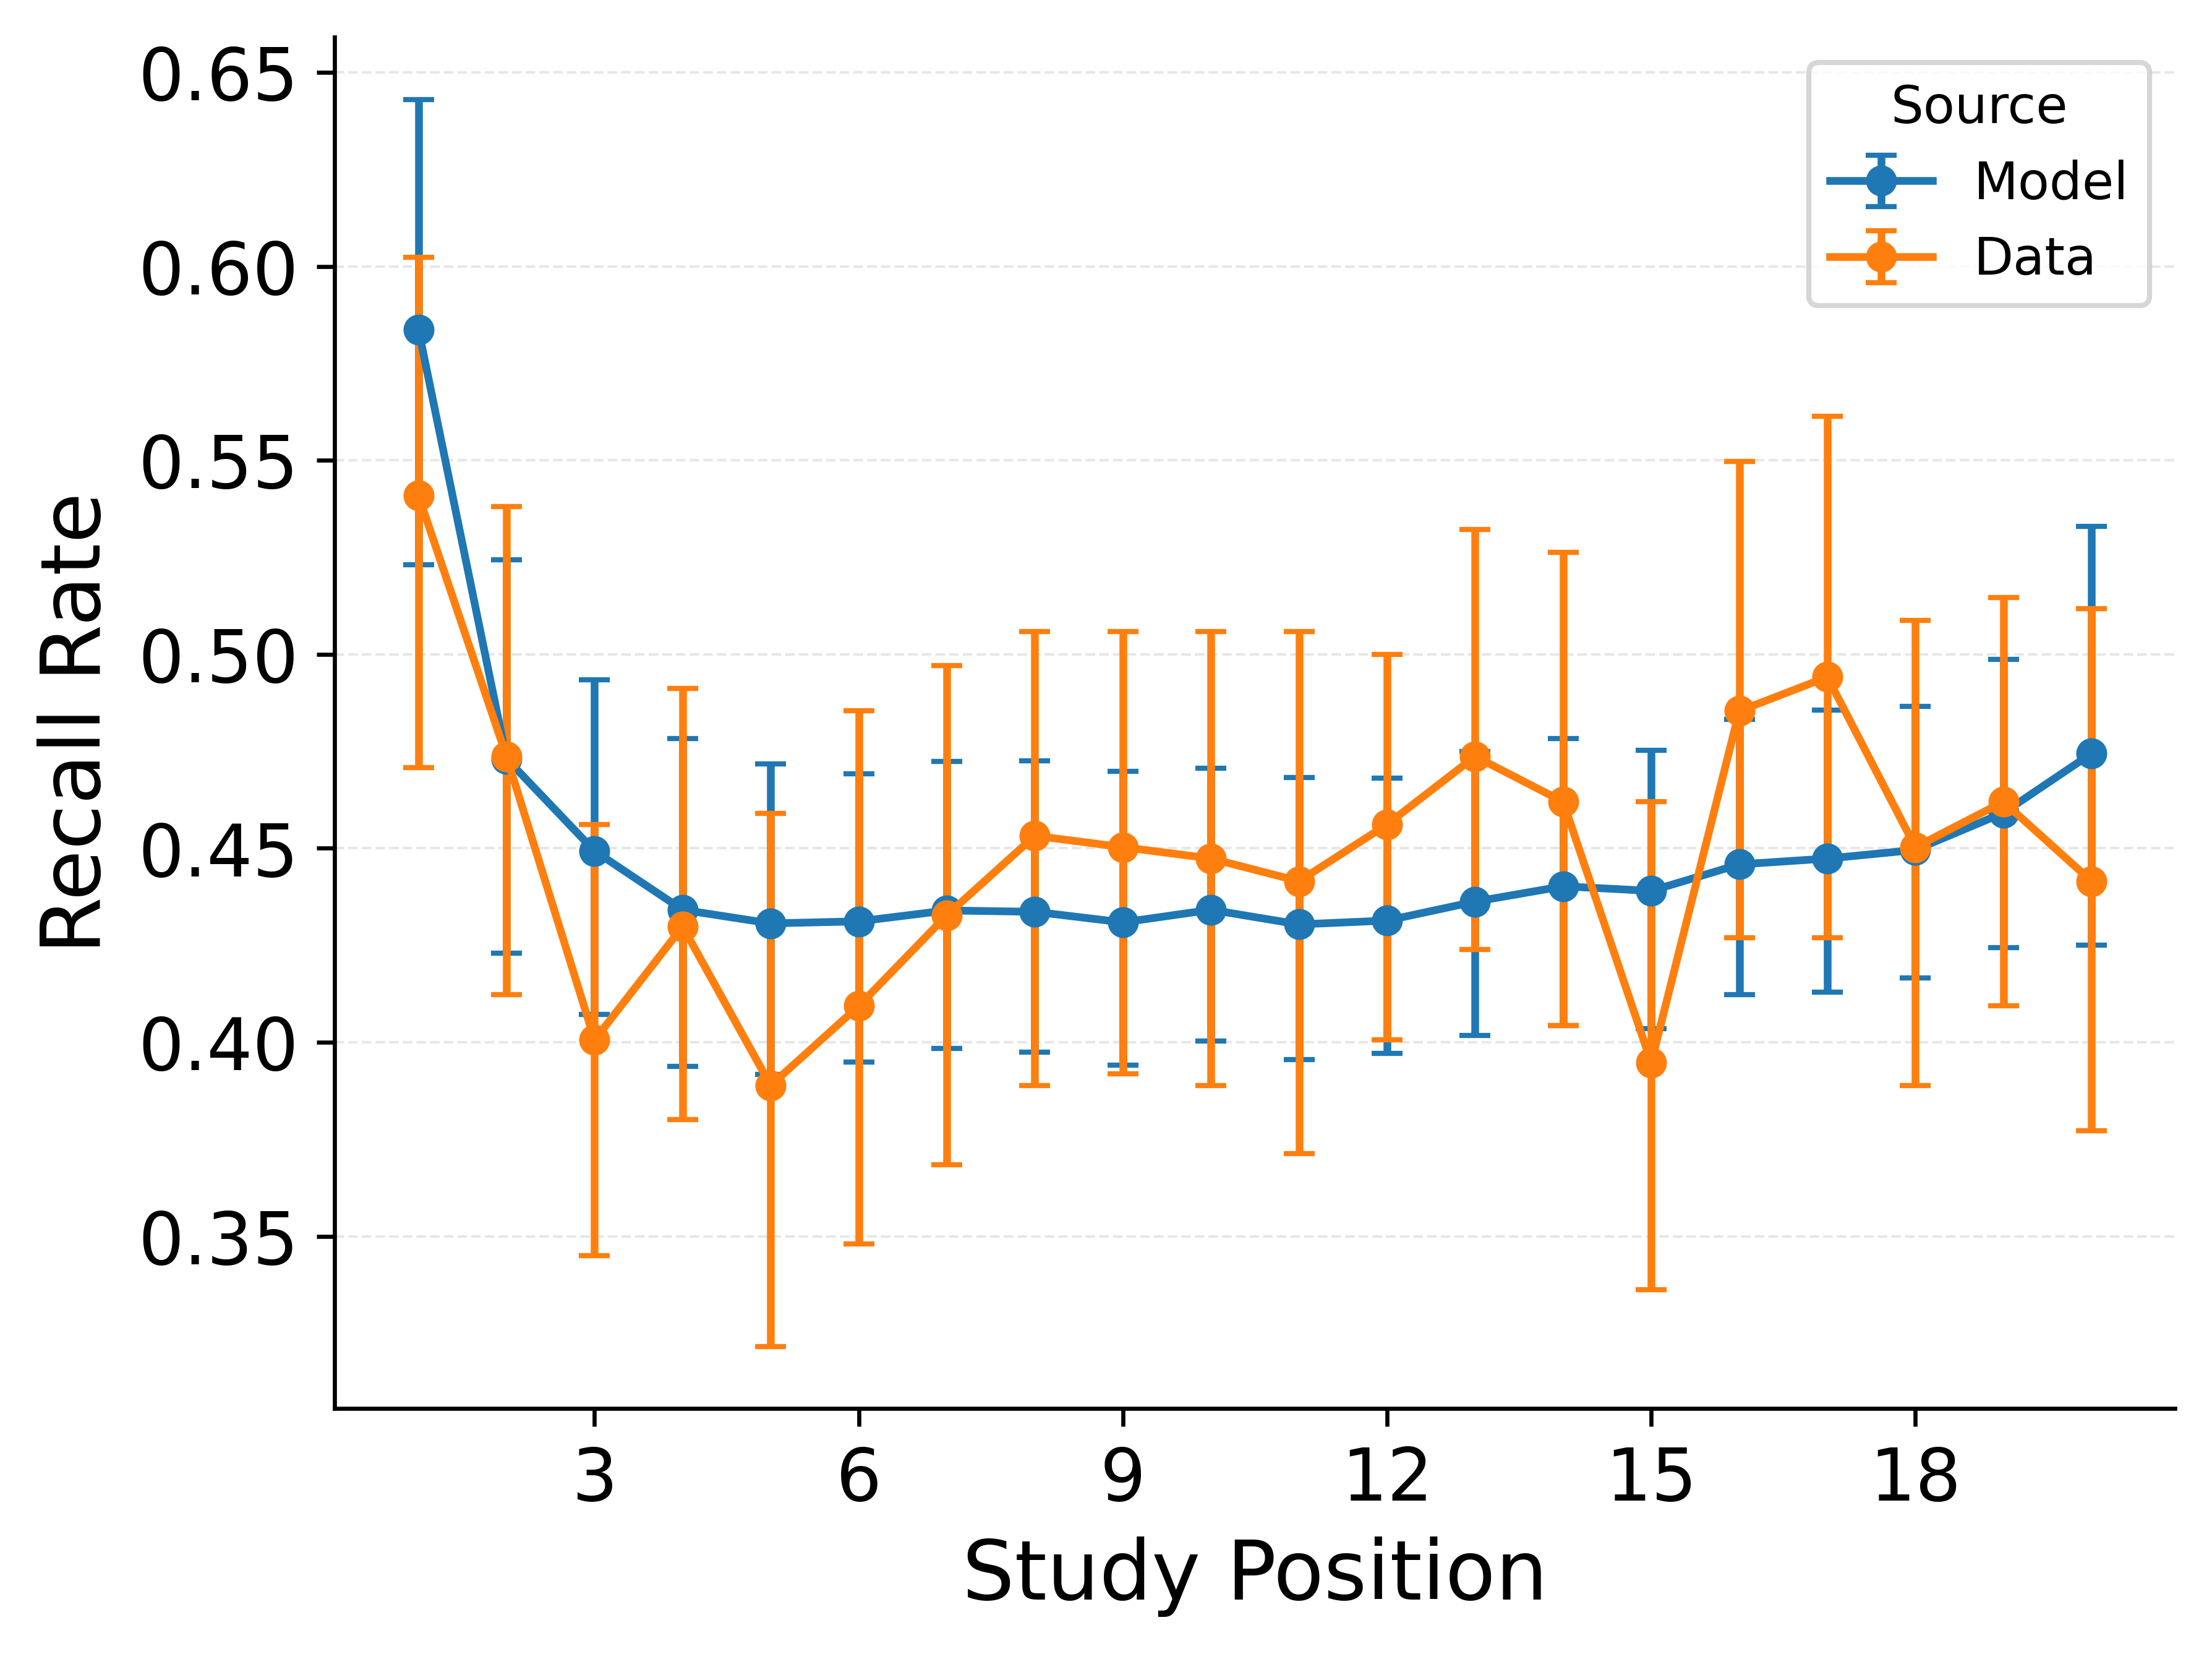

![](/Users/jordangunn/jaxcmr/projects/TalmiEEG/results/figures/fitting/TalmiEEG_EEGLPPParsimonious_50_set_likelihood_fixed_term_best_of_3_crp.png)


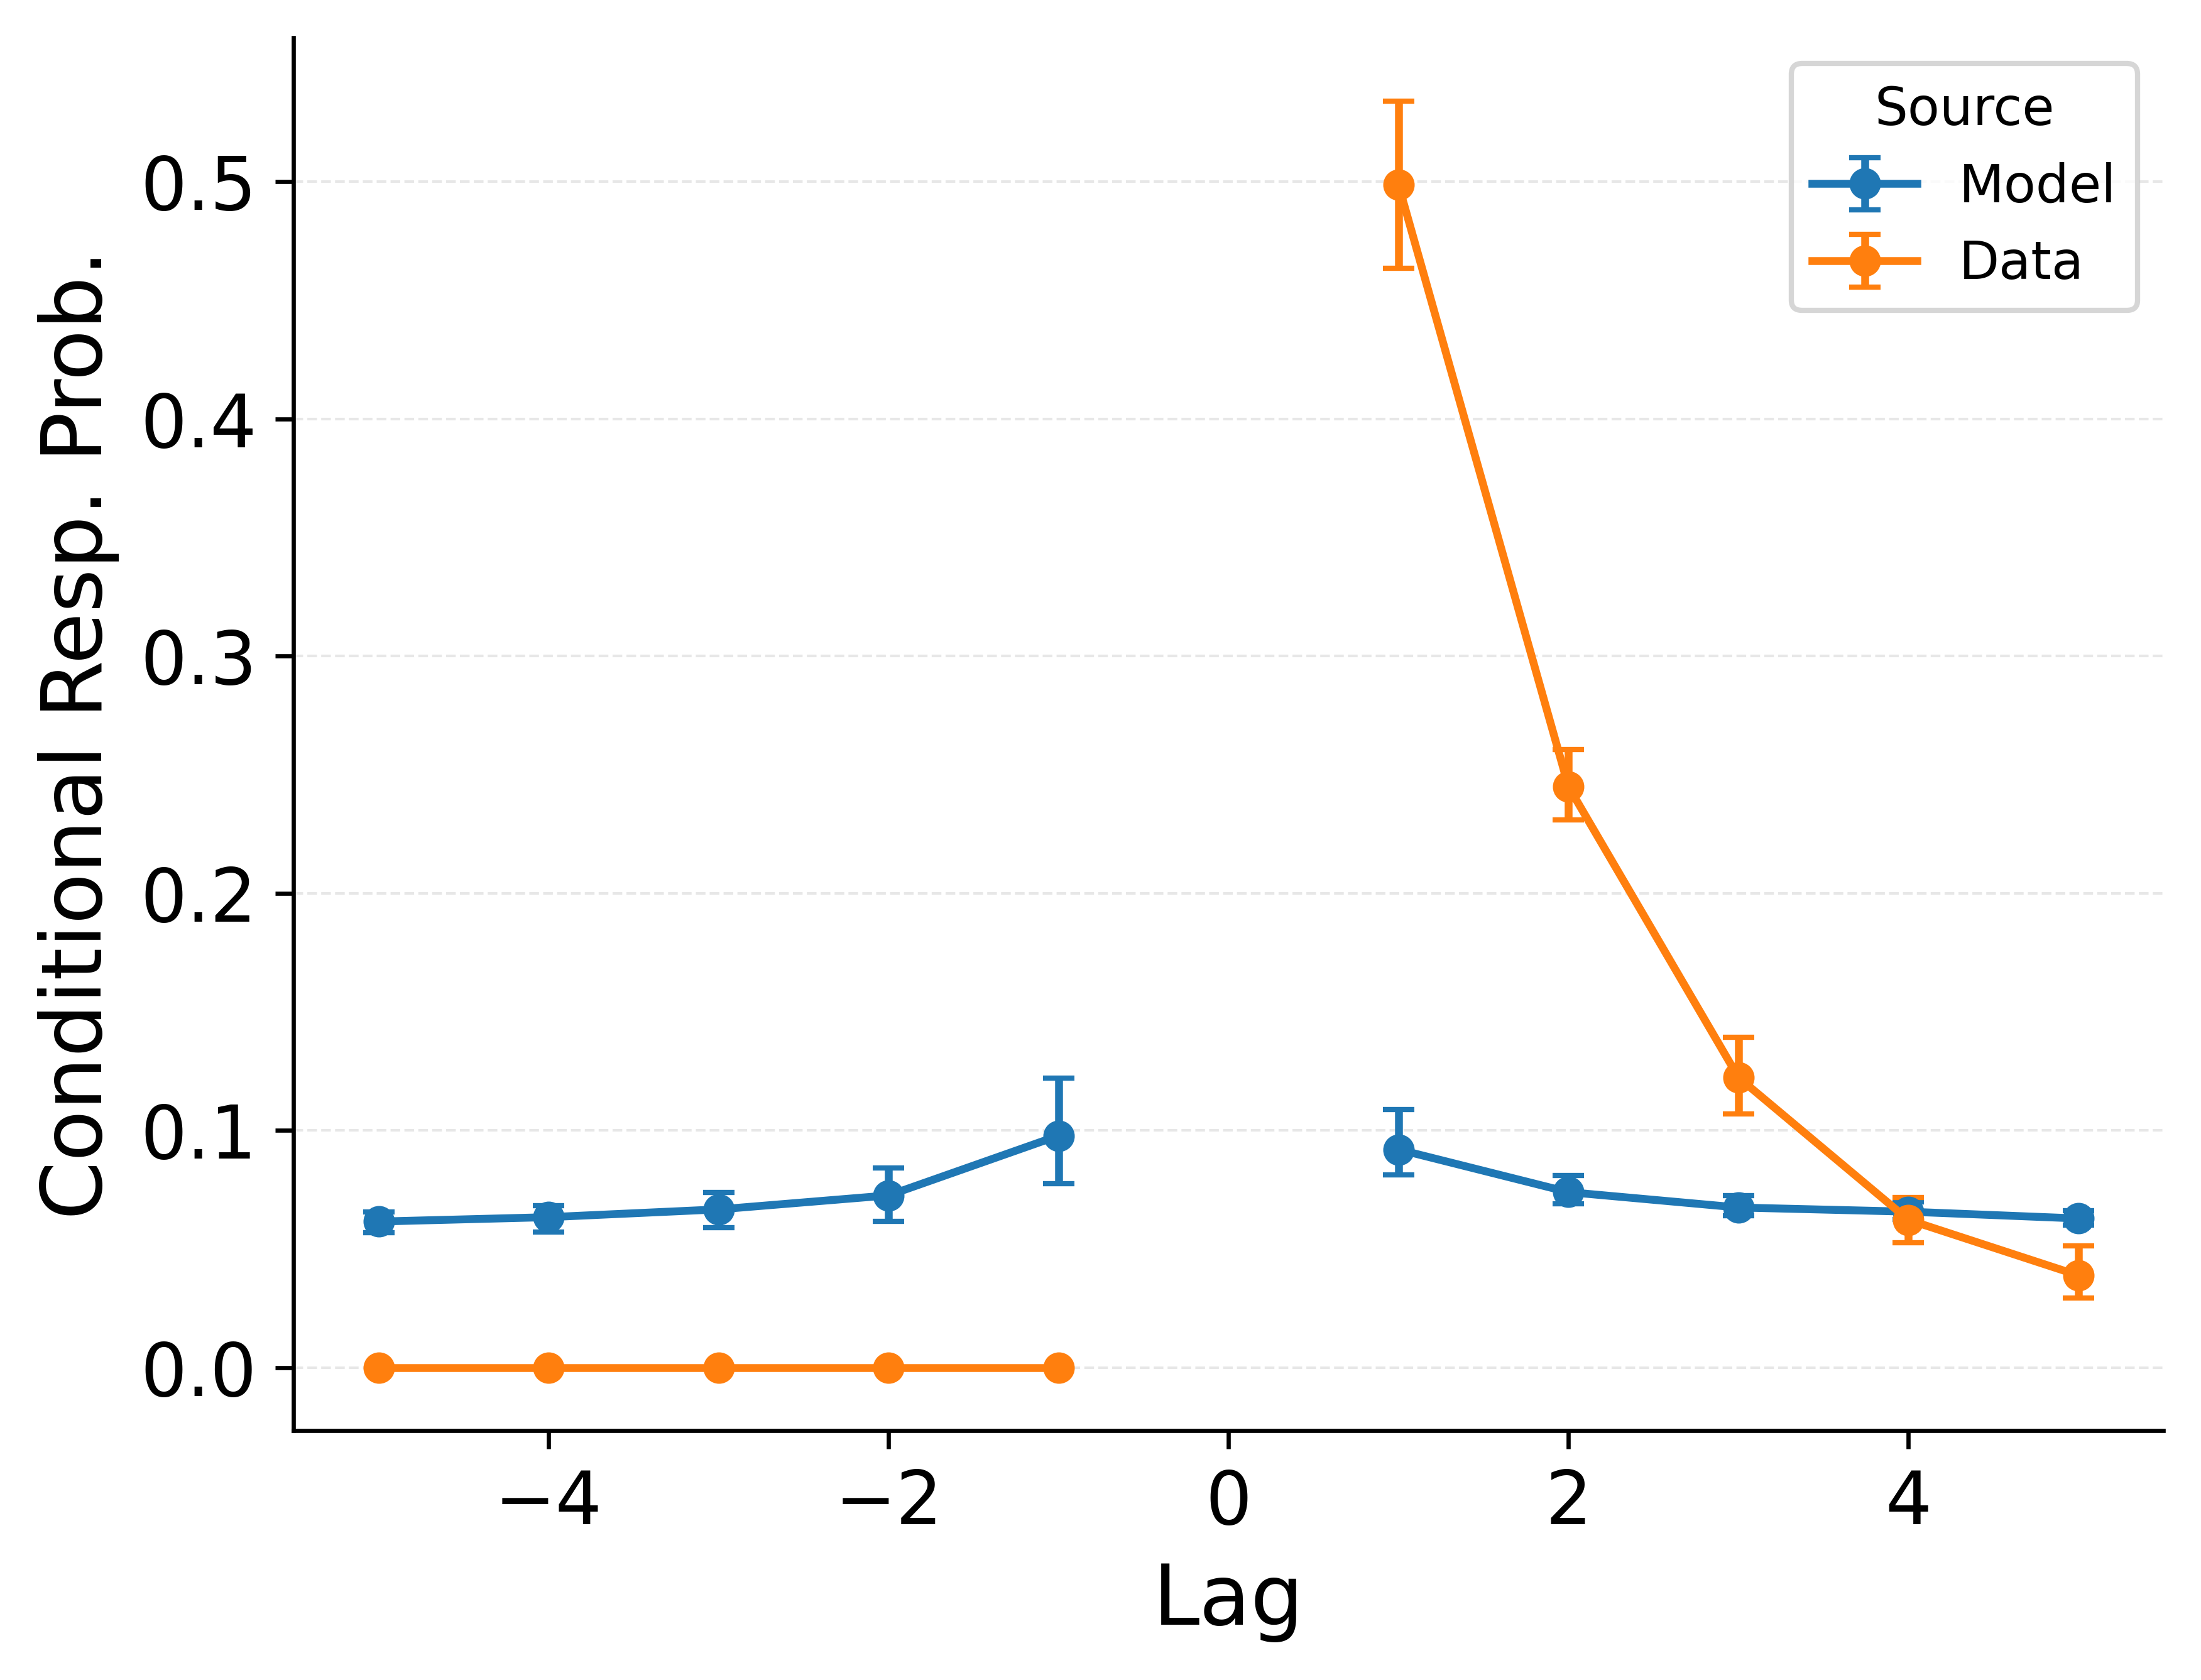

![](/Users/jordangunn/jaxcmr/projects/TalmiEEG/results/figures/fitting/TalmiEEG_EEGLPPParsimonious_50_set_likelihood_fixed_term_best_of_3_pnr.png)


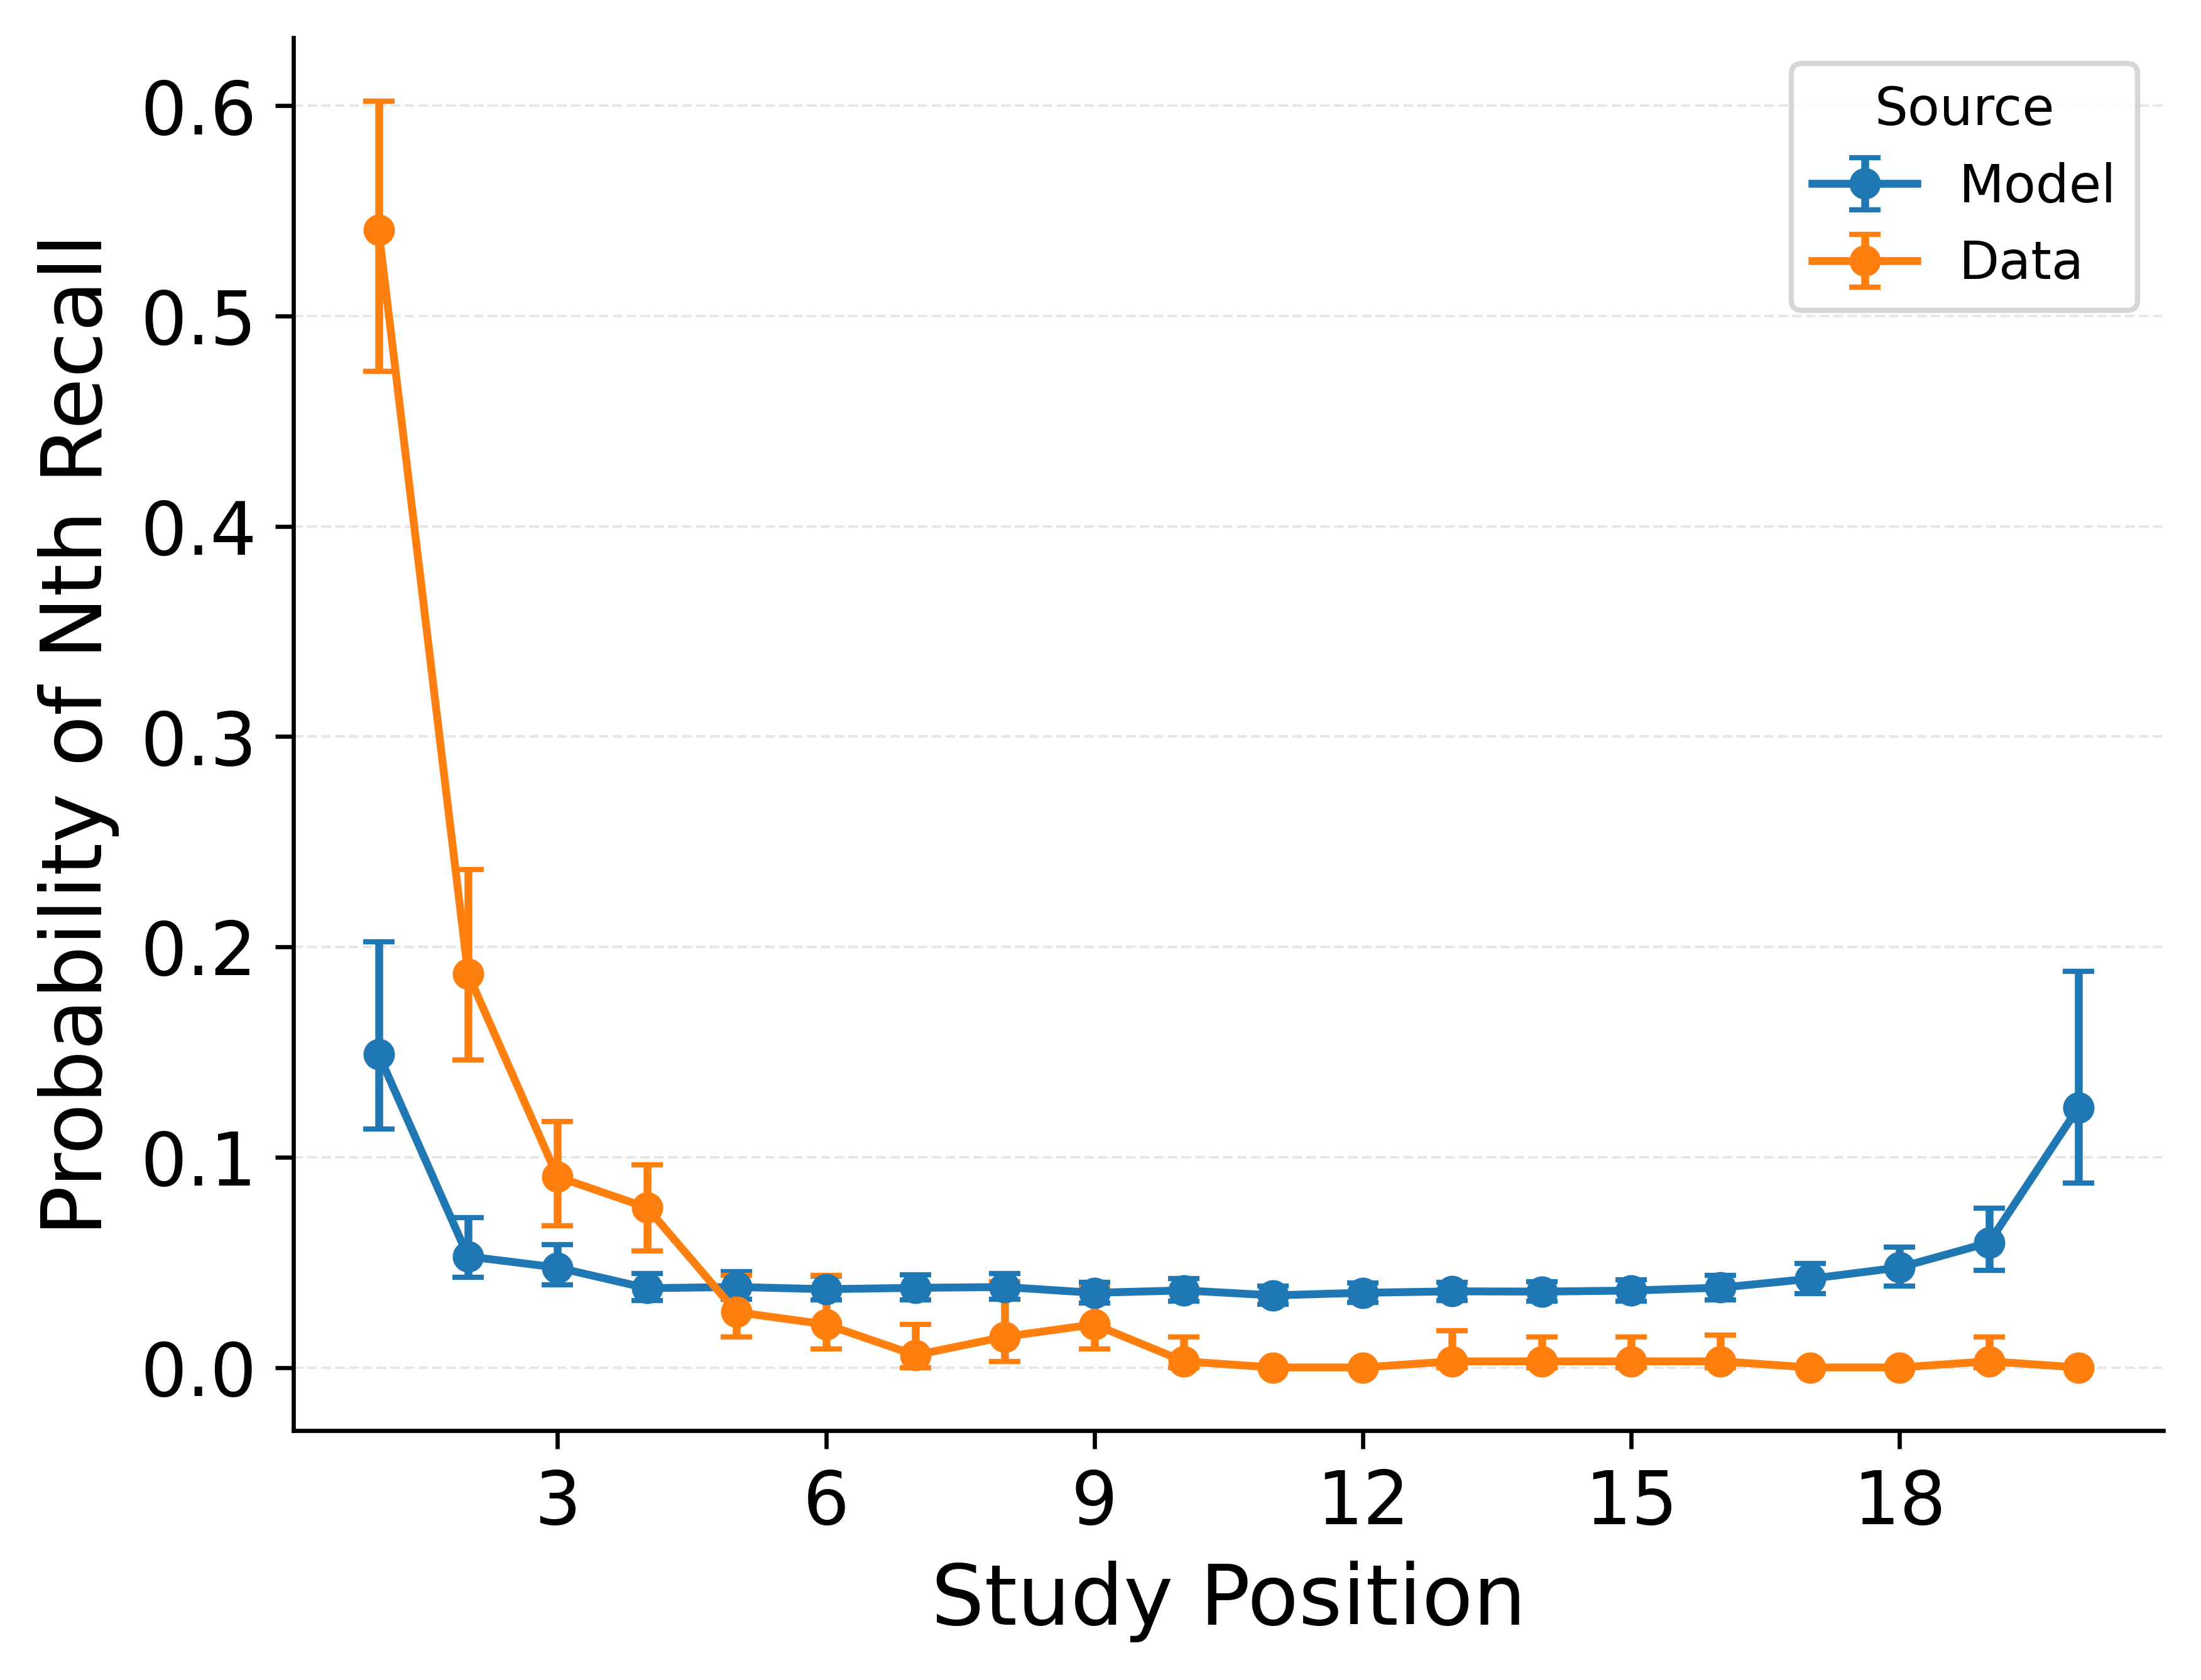

In [4]:
for partial_params in varied_parameters:

    params = base_params.copy() | {
        k: v for k, v in partial_params.items() if k != "enabled"
    }

    data_tag = params["data_tag"]
    model_name = params["model_name"]
    base_run_tag = params["base_run_tag"]
    best_of = params["best_of"]
    fit_tag = f"{base_run_tag}_best_of_{best_of}"
    max_subjects = params["max_subjects"]
    if max_subjects:
        fit_tag += f"_nsubs_{max_subjects}"

    output_path = (
        f"{find_project_root()}/projects/TalmiEEG/notebooks/rendered/"
        f"fitting_{data_tag}_{model_name}_{fit_tag}.ipynb"
    )
    print(output_path)

    pm.execute_notebook(
        f"{find_project_root()}/projects/TalmiEEG/notebooks/templates/fitting.ipynb",
        output_path,
        parameters=params,
        progress_bar=True,
    )

    for analysis_cfg in params["single_analysis_configs"]:
        figure_str = (
            f"{data_tag}_{model_name}_{fit_tag}_{analysis_cfg['figure_suffix']}.png"
        )
        figure_path = os.path.join(
            f"{find_project_root()}/projects/TalmiEEG/results/figures/fitting/{figure_str}"
        )
        print(f"![]({figure_path})")
        display(Image(filename=figure_path, width=600))

    for analysis_cfg in params["comparison_analysis_configs"]:
        figure_str = (
            f"{data_tag}_{model_name}_{fit_tag}_{analysis_cfg['figure_suffix']}.png"
        )
        figure_path = os.path.join(
            f"{find_project_root()}/projects/TalmiEEG/results/figures/fitting/{figure_str}"
        )
        print(f"![]({figure_path})")
        display(Image(filename=figure_path, width=600))
